In [ ]:
from IPython.display import HTML

# needed for proper pdf export
HTML("""
<style>

/* ── General text ───────────────────────── */
body, .jp-Notebook, .rendered_html {
    font-size: 9px !important;
    line-height: 1.3 !important;
}

/* ── Headings (FIX BIG TITLES) ─────────── */
.rendered_html h1 { font-size: 14px !important; }
.rendered_html h2 { font-size: 12px !important; }
.rendered_html h3 { font-size: 11px !important; }
.rendered_html h4 { font-size: 10px !important; }
.rendered_html h5 { font-size: 9px !important; }
.rendered_html h6 { font-size: 8px !important; }

/* ── Code (readable) ───────────────────── */
div.input_area pre,
div.input_area code,
.jp-CodeCell .cm-content,
.jp-InputArea-editor,
div.output_area pre,
div.output_area code {
    font-size: 9px !important;
    line-height: 1.3 !important;
}

/* ── Tables (FIX BIG TABLE TEXT) ───────── */
.dataframe, table {
    font-size: 6px !important;
    width: 100% !important;
    table-layout: auto !important;
}

/* Headers smaller + bold */
.dataframe th, table th {
    font-size: 6px !important;
    font-weight: 600 !important;
    padding: 2px 3px !important;
}

/* Cells */
.dataframe td, table td {
    font-size: 6px !important;
    padding: 2px 3px !important;
    white-space: normal !important;
    word-break: break-word !important;
}

/* ── Outputs scroll nicely ─────────────── */
.output_area, .output, .jp-OutputArea-output {
    overflow-x: auto !important;
    max-width: 100% !important;
}

/* ── Print optimization ────────────────── */
@media print {

    body {
        font-size: 8px !important;
    }

    .rendered_html h1 { font-size: 12px !important; }
    .rendered_html h2 { font-size: 10px !important; }
    .rendered_html h3 { font-size: 9px !important; }

    pre, code {
        font-size: 7px !important;
        line-height: 1.2 !important;
        white-space: pre-wrap !important;
    }

    .dataframe, table {
        font-size: 5.5px !important;
    }

    table {
        page-break-inside: avoid !important;
    }
}

</style>
""")

---
*This notebook is best viewed interactively in Jupyter. The interactive exploration widgets (Analysis 9) require a live kernel and are not available in the PDF export. A static version and the source code are available at: [GitHub repo link](https://github.com/estebangatein/afri-val)*

# Personal Information
Name: **Esteban Gatein**

StudentID: **16293029**

Email: [**esteban.gatein@student.uva.nl**](mailto:esteban.gatein@student.uva.nl)

Submitted on: **23.03.2026**

# Data Context

This EDA explores African-language NLP datasets from **AfroBench** (Ojo et al., 2025) that will form the foundation of a unified evaluation benchmark for auditing LLM-as-a-Judge systems in African languages. The datasets were selected based on four criteria: task diversity, language coverage across African language families, data volume per language, and feasibility within the thesis timeline.

Following the reliability definitions from Gu et al. (2025), the benchmark will evaluate LLM judges across multiple dimensions: **agreement with human annotations**, **bias** (cultural, language, diversity, length, style), and **robustness** (prompt perturbation). Each dataset is linked to one of two evaluation scenarios:
- **Scenario 1 — Verification**: the judge receives an input and a label and decides whether the label is correct (used for classification, NLI, QA, and reasoning tasks)
- **Scenario 2 — Rating**: the judge receives an input and an output and scores it on a 1–5 scale (used for generation tasks: translation, summarization)

We work with **10 datasets** across different NLP task categories, loaded through a **registry pattern** so that extending the EDA requires only adding one entry:

- **MasakhaNER 2.0** (Adelani et al., 2022): Named Entity Recognition for 20 African languages. Token-level BIO annotations for PER, ORG, LOC, and DATE. *Scenario 1. Bias targets: cultural (names, places), concreteness.*

- **AfriSenti** (Muhammad et al., 2023): Sentiment analysis for 14 African languages, 110,000+ tweets across 3 classes. SemEval-2023 Task 12 with published baselines. *Scenario 1. Bias targets: cultural, diversity, language.*

- **MasakhaNEWS** (Adelani et al., 2023): News topic classification for 16 African languages across 7 categories. *Scenario 1. Bias targets: concreteness.*

- **AfriHate** (Muhammad et al., 2025): Hate speech detection for 15 African languages. Three classes: hate, abuse, normal. Most subjective classification task. *Scenario 1. Bias targets: cultural, diversity.*

- **AfriXNLI** (Adelani et al., 2024b): Natural language inference for 17 African languages. Premise-hypothesis pairs classified as entailment, neutral, or contradiction. *Scenario 1. Bias targets: language, style (translated data).*

- **AfriQA** (Ogundepo et al., 2023): Cross-lingual QA for 10 African languages with English/French contexts. *Scenario 1. Bias targets: cultural (cross-lingual), language.*

- **Belebele** (Bandarkar et al., 2024): Reading comprehension for 25 African languages. Multiple-choice format with Flores passages. *Scenario 1. Bias targets: script, language.*

- **AfriMGSM** (Adelani et al., 2024b): Math reasoning for 17 African languages. Grade-school problems with unambiguous numerical answers. *Scenario 1. Bias targets: language (reasoning), concreteness.*

- **MAFAND-MT** (Adelani et al., 2022): Machine translation for 21 English/French–African language pairs. *Scenario 2. Bias targets: length, language, style, cultural.*

- **XLSum** (Hasan et al., 2021): News summarization for 9 African languages. *Scenario 2. Bias targets: length, language, style, cultural.*

Together, these 10 datasets cover **~40 unique African languages** across 4 language families (Niger-Congo Bantu, Niger-Congo non-Bantu, Afroasiatic, Nilo-Saharan) and 1 Austronesian language (Malagasy), spanning the full subjectivity spectrum from fully objective (NER, math) to highly subjective (hate speech, summarization, translation quality).

# Data Description

<table>
<thead><tr><th>Analysis</th><th>Focus</th><th>Relevant dimension</th><th>RQ</th></tr></thead>
<tbody>
<tr><td>1. Dataset structure & features</td><td>What does each data point look like?</td><td>Foundation</td><td>—</td></tr>
<tr><td>2. Corpus-level statistics</td><td>How much data per language/split?</td><td>Volume, feasibility</td><td>RQ1, RQ3</td></tr>
<tr><td>3. Language coverage & overlap</td><td>Which languages can we evaluate across tasks?</td><td>Language diversity</td><td>RQ1, RQ3</td></tr>
<tr><td>4. Label/class balance</td><td>Are labels evenly distributed?</td><td>Diversity bias, label bias</td><td>RQ2, RQ3</td></tr>
<tr><td>5. Text length distributions</td><td>How do input sizes vary across languages?</td><td>Length bias</td><td>RQ1, RQ2</td></tr>
<tr><td>6. Data quality & anomalies</td><td>Empty texts, duplicates, annotation errors?</td><td>Data cleaning, robustness</td><td>RQ1</td></tr>
<tr><td>7. Language family analysis</td><td>Do linguistic families show different patterns?</td><td>Language bias, cultural bias</td><td>RQ1, RQ2</td></tr>
<tr><td>8. Baseline estimation</td><td>What is the performance floor per language?</td><td>Agreement baseline</td><td>RQ1, RQ3</td></tr>
<tr><td>9. Interactive exploration</td><td>Drill down into individual languages</td><td>Understanding</td><td>RQ2, RQ4</td></tr>
<tr><td>10. Split proportions</td><td>Are train/val/test splits consistent?</td><td>Robustness</td><td>RQ1, RQ3</td></tr>
</tbody>
</table>

## Setup & Dataset Registry
The registry defines all datasets in one place. Every analysis below loops over this registry, so **adding a new dataset = adding one dict entry + uncommenting one line**.

In [8]:
import warnings; warnings.filterwarnings("ignore")
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from collections import Counter
from datasets import load_dataset, get_dataset_config_names
from IPython.display import display, Markdown
from datasets import disable_progress_bars
disable_progress_bars()

plt.rcParams.update({
    "figure.figsize": (14, 6), "axes.titlesize": 14, "axes.labelsize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "figure.dpi": 120,
    "axes.spines.top": False, "axes.spines.right": False,
})
PAL = sns.color_palette("Set2", 12)

In [53]:
# DATASET REGISTRY
REGISTRY = {
    # token classification
    "MasakhaNER2": {
        "hf_path": "masakhane/masakhaner2",
        "task_type": "token_classification",
        "text_field": "tokens",
        "label_field": "ner_tags",
        "label_map": {0:"O",1:"B-PER",2:"I-PER",3:"B-ORG",4:"I-ORG",
                       5:"B-LOC",6:"I-LOC",7:"B-DATE",8:"I-DATE"},
        "eval_scenario": 1,
        "paper": "Adelani et al. (2022) — EMNLP",
        "_display_fields": [("tokens", "tokens"), ("tags", "ner_tags")],
    },
    # text classification
    "AfriSenti": {
        "hf_path": "masakhane/afrisenti",
        "task_type": "text_classification",
        "text_field": "tweet",
        "label_field": "label",
        "label_map": None,
        "eval_scenario": 1,
        "paper": "Muhammad et al. (2023) — EMNLP / SemEval-2023",
        "_display_fields": [("text", "tweet"), ("label", "label")],
    },
    "MasakhaNEWS": {
        "hf_path": "masakhane/masakhanews",
        "task_type": "text_classification",
        "text_field": "headline",
        "label_field": "category",
        "label_map": None,
        "eval_scenario": 1,
        "paper": "Adelani et al. (2023)",
        "_display_fields": [("headline", "headline"), ("category", "category")],
    },
    "AfriHate": {
        "hf_path": "afrihate/afrihate",
        "task_type": "text_classification",
        "text_field": "tweet",
        "label_field": "label",
        "label_map": None,
        "eval_scenario": 1,
        "paper": "Muhammad et al. (2025) — NAACL",
        "_display_fields": [("tweet", "tweet"), ("label", "label")],
    },
    # natural language inference
    "AfriXNLI": {
        "hf_path": "masakhane/afrixnli",
        "task_type": "nli",
        "text_field": "premise",
        "second_text_field": "hypothesis",
        "label_field": "label",
        "label_map": {0: "entailment", 1: "neutral", 2: "contradiction"},
        "eval_scenario": 1,
        "paper": "Adelani et al. (2024b) — IrokoBench",
        "_display_fields": [("premise", "premise"), ("hypothesis", "hypothesis"), ("label", "label")],
    },
    # QA
    "AfriQA": {
        "hf_path": "masakhane/afriqa",
        "task_type": "question_answering",
        "text_field": "question",
        "label_field": None,
        "label_map": None,
        "answer_field": "answers",
        "eval_scenario": 1,
        "paper": "Ogundepo et al. (2023)",
        "_display_fields": [("question", "question"), ("answer", "answers")],
    },
    "Belebele": {
        "hf_path": "facebook/belebele",
        "task_type": "reading_comprehension",
        "text_field": "flores_passage",
        "question_field": "question",
        "choice_fields": ["mc_answer1", "mc_answer2", "mc_answer3", "mc_answer4"],
        "label_field": "correct_answer_num",
        "label_map": None,
        "eval_scenario": 1,
        "paper": "Bandarkar et al. (2024) — ACL",
        "_configs": [
            "amh_Ethi", "bam_Latn", "fuv_Latn", "gaz_Latn",
            "hau_Latn", "ibo_Latn", "kin_Latn", "lin_Latn",
            "lug_Latn", "luo_Latn", "nso_Latn", "nya_Latn",
            "plt_Latn", "sna_Latn", "som_Latn", "sot_Latn",
            "ssw_Latn", "swh_Latn", "tir_Ethi", "tsn_Latn",
            "tso_Latn", "wol_Latn", "xho_Latn", "yor_Latn",
            "zul_Latn",
        ],
        "_lang_code_fn": lambda c: {"swh":"swa","gaz":"orm"}.get(c.split("_")[0], c.split("_")[0]),
        "_display_fields": [("passage", "flores_passage"), ("question", "question"),
                        ("A", "mc_answer1"), ("B", "mc_answer2"),
                        ("C", "mc_answer3"), ("D", "mc_answer4"),
                        ("correct", "correct_answer_num")],
    },
    # math reasoning
    "AfriMGSM": {
        "hf_path": "masakhane/afrimgsm",
        "task_type": "math_reasoning",
        "text_field": "question",
        "label_field": "answer_number",
        "answer_field": "answer",
        "label_map": None,
        "eval_scenario": 1,
        "paper": "Adelani et al. (2024b) — IrokoBench",
        "_display_fields": [("question", "question"), ("reasoning", "answer"), ("answer", "answer_number")],
    },
    # text generation
    "MAFAND-MT": {
        "hf_path": "masakhane/mafand",
        "task_type": "translation",
        "text_field": "translation",
        "label_field": None,
        "label_map": None,
        "eval_scenario": 2,
        "paper": "Adelani et al. (2022) — NAACL",
        "_lang_code_fn": lambda c: c.split("-")[-1],
        "_display_fields": [("translation", "translation")],
    },
    "XLSum": {
        "hf_path": "csebuetnlp/xlsum",
        "task_type": "summarization",
        "text_field": "text",
        "label_field": None,
        "label_map": None,
        "summary_field": "summary",
        "eval_scenario": 2,
        "paper": "Hasan et al. (2021)",
        "_configs": [
            "amharic", "hausa", "igbo", "oromo", "pidgin",
            "somali", "swahili", "tigrinya", "yoruba",
        ],
        "_lang_code_fn": lambda c: {"amharic":"amh","hausa":"hau","igbo":"ibo",
            "oromo":"orm","pidgin":"pcm","somali":"som","swahili":"swa",
            "tigrinya":"tir","yoruba":"yor"}.get(c, c),
        "_display_fields": [("text", "text"), ("summary", "summary")],
    },
}

# language metadata
LANG_NAMES = {
    "bam":"Bambara","ewe":"Ewe","fon":"Fon","ibo":"Igbo","kin":"Kinyarwanda",
    "lug":"Luganda","luo":"Luo","nya":"Chichewa","pcm":"Nigerian Pidgin",
    "sna":"chiShona","swa":"Swahili","tsn":"Setswana","twi":"Twi","wol":"Wolof",
    "xho":"isiXhosa","yor":"Yoruba","zul":"isiZulu","tso":"Xitsonga","bbj":"Ghomala",
    "amh":"Amharic","hau":"Hausa","orm":"Oromo","oro":"Oromo","tir":"Tigrinya",
    "arq":"Algerian Arabic","ary":"Moroccan Arabic","por":"Mozambican Portuguese",
    "eng":"English","en":"English", "mos":"Mossi","bem":"Bemba","fra":"French","lin":"Lingala",
    "run":"Kirundi","som":"Somali", "fuv":"Fulfulde", "nso":"Northern Sotho", "plt":"Malagasy",
    "sot":"Southern Sotho", "ssw":"Swati", 'vai': 'Vai',
}
LANG_FAMILIES = {
    "Niger-Congo (Bantu)":["swa","zul","xho","sna","kin","lug","nya","tsn",
                            "lin","run","bem","tso","nso","sot","ssw"],
    "Niger-Congo (non-Bantu)":["ibo","yor","ewe","fon","twi","wol","pcm",
                                "bbj","bam","mos","fuv", "vai"],
    "Afroasiatic":["amh","hau","orm","oro","tir","arq","ary","som"],
    "Nilo-Saharan":["luo"],
    "Austronesian":["plt"],
    "Other":["por","fra","eng","en"],
}
FAM_COLORS = {
    "Niger-Congo (Bantu)":"#006BC2",
    "Niger-Congo (non-Bantu)":"#7BD5FF",
    "Afroasiatic":"#FF9800",
    "Nilo-Saharan":"#4CAF50",
    "Austronesian":"#E91E63",
    "Other":"#9C27B0",
    "Unknown":"#999",
}

# utils functions
def lname(c): return LANG_NAMES.get(c, c)
def lfamily(c):
    for f, codes in LANG_FAMILIES.items():
        if c in codes: return f
    return "Unknown"
def default_split(ds):
    """Return first available split — prefer train, fall back to validation/test."""
    for sp in ["train", "validation", "test"]:
        if sp in ds:
            return sp
    return list(ds.keys())[0]

def normalize_lang_code(code, cfg):
    """Normalize config names to base language codes.
    e.g. 'en-amh' → 'amh', 'fr-bam' → 'bam'. Passes through if no normalizer."""
    fn = cfg.get("_lang_code_fn")
    return fn(code) if fn else code

print(f"Registry contains {len(REGISTRY)} datasets: {list(REGISTRY.keys())}")

Registry contains 10 datasets: ['MasakhaNER2', 'AfriSenti', 'MasakhaNEWS', 'AfriHate', 'AfriXNLI', 'AfriQA', 'Belebele', 'AfriMGSM', 'MAFAND-MT', 'XLSum']


### Data Loading
We load all datasets from HuggingFace Hub in one generic loop. Data is cached locally after first download.

In [10]:
FALLBACK_CONFIGS = {
    "MasakhaNER2": ["bam","bbj","ewe","fon","hau","ibo","kin","lug","luo","mos",
                     "nya","pcm","sna","swa","tsn","twi","wol","xho","yor","zul"],
    "AfriQA": ["bem","fon","hau","ibo","kin","swa","twi","wol","yor","zul"],
    "MasakhaPOS": ["bam","bbj","ewe","fon","hau","ibo","kin","lug","luo","mos",
                    "nya","pcm","sna","swa","tsn","twi","wol","xho","yor","zul"],
    "MAFAND-MT": ["en-amh","en-hau","en-ibo","en-kin","en-lug","en-luo","en-nya",
                   "en-pcm","en-sna","en-swa","en-tsn","en-twi","en-xho","en-yor",
                   "en-zul","fr-bam","fr-bbj","fr-ewe","fr-fon","fr-mos","fr-wol"],
}


ALL_DATA = {}

for ds_name, cfg in REGISTRY.items():
    print(f"Loading {ds_name} ({cfg['hf_path']})...")
    configs = cfg.get("_configs") or get_dataset_config_names(cfg["hf_path"])
    configs = [c for c in configs if c != "default"]
    print(f"  Configs ({len(configs)}): {configs}")
    data = {}
    for lang in configs:
        data[lang] = load_dataset(cfg["hf_path"], lang)
    ALL_DATA[ds_name] = data
    
    if cfg["task_type"] in ["text_classification", "nli"] and cfg.get("label_field") and len(data) > 0:
        sample_lang = list(data.keys())[0]
        sp = default_split(data[sample_lang])
        sample_val = data[sample_lang][sp][cfg["label_field"]][0]
        cfg["_label_is_string"] = isinstance(sample_val, str)
        if cfg["_label_is_string"]:
            cfg["label_map"] = {v: v for v in sorted(set(data[sample_lang][sp][cfg["label_field"]]))}
            print(f"  Labels (string): {list(cfg['label_map'].keys())}")
        elif hasattr(data[sample_lang][sp].features[cfg["label_field"]], "names"):
            names = data[sample_lang][sp].features[cfg["label_field"]].names
            cfg["label_map"] = {i: n for i, n in enumerate(names)}
            cfg["_label_is_string"] = False
            print(f"  Labels (int->name): {cfg['label_map']}")
    
    print(f"  Done: {len(data)} languages\n")

print(f"=== All done: {sum(len(d) for d in ALL_DATA.values())} total language-dataset pairs ===")

Loading MasakhaNER2 (masakhane/masakhaner2)...
  Configs (20): ['bam', 'bbj', 'ewe', 'fon', 'hau', 'ibo', 'kin', 'lug', 'luo', 'mos', 'nya', 'pcm', 'sna', 'swa', 'tsn', 'twi', 'wol', 'xho', 'yor', 'zul']
  Done: 20 languages

Loading AfriSenti (masakhane/afrisenti)...
  Configs (15): ['amh', 'arq', 'ary', 'eng', 'hau', 'ibo', 'kin', 'orm', 'pcm', 'por', 'swa', 'tir', 'tso', 'twi', 'yor']
  Labels (string): ['negative', 'neutral', 'positive']
  Done: 15 languages

Loading MasakhaNEWS (masakhane/masakhanews)...
  Configs (16): ['amh', 'eng', 'fra', 'hau', 'ibo', 'lin', 'lug', 'orm', 'pcm', 'run', 'sna', 'som', 'swa', 'tir', 'xho', 'yor']
  Labels (string): ['business', 'health', 'politics', 'sports']
  Done: 16 languages

Loading AfriHate (afrihate/afrihate)...
  Configs (15): ['amh', 'arq', 'ary', 'hau', 'ibo', 'kin', 'orm', 'som', 'swa', 'pcm', 'tir', 'twi', 'xho', 'yor', 'zul']
  Labels (string): ['Abuse', 'Hate', 'Normal']
  Done: 15 languages

Loading AfriXNLI (masakhane/afrixnli)..

hausa/train/0000.parquet:   0%|          | 0.00/8.42M [00:00<?, ?B/s]

hausa/test/0000.parquet:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

hausa/validation/0000.parquet:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

igbo/train/0000.parquet:   0%|          | 0.00/5.19M [00:00<?, ?B/s]

...

tigrinya/validation/0000.parquet:   0%|          | 0.00/1.44M [00:00<?, ?B/s]

yoruba/train/0000.parquet:   0%|          | 0.00/9.14M [00:00<?, ?B/s]

yoruba/test/0000.parquet:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

yoruba/validation/0000.parquet:   0%|          | 0.00/1.09M [00:00<?, ?B/s]

  Done: 9 languages

=== All done: 168 total language-dataset pairs ===


### Analysis 1: Dataset Structure & Features
We inspect what a data point looks like for each dataset. This is essential for designing the LLM-as-a-judge evaluation prompts later.

In [ ]:
for ds_name, cfg in REGISTRY.items():
    data = ALL_DATA[ds_name]
    if len(data) == 0:
        print(f"⚠ {ds_name}: no data loaded, skipping\n")
        continue
    sample_lang = list(data.keys())[0]
    ds = data[sample_lang]
    sp = default_split(ds)

    print("=" * 70)
    print(f"{ds_name} — Structure (example: {lname(sample_lang)})")
    print("=" * 70)
    print(f"  Task type:  {cfg['task_type']}")
    print(f"  Splits:     {list(ds.keys())}")
    print(f"  Features:   {ds[sp].features}")
    if cfg.get("label_map"):
        print(f"  Label map:  {cfg['label_map']}")
    print(f"  Paper:      {cfg['paper']}")

    # show 2 samples using _display_fields
    print(f"\n  Sample data points:")
    for i in range(min(2, len(ds[sp]))):
        ex = ds[sp][i]
        print(f"    [{i}]")
        for label, field in cfg.get("_display_fields", []):
            val = ex.get(field, "N/A")
            # format based on type
            if isinstance(val, dict):  # translation pairs
                for k, v in val.items():
                    print(f"        {k}: {str(v)[:120]}")
            elif isinstance(val, list):  # token sequences
                print(f"        {label}: {' '.join(str(v) for v in val[:15])}{'...' if len(val) > 15 else ''}")
            elif cfg.get("label_map") and field == cfg.get("label_field"):
                print(f"        {label}: {cfg['label_map'].get(val, val)}")
            else:
                print(f"        {label}: {str(val)[:120]}")
    print()

MasakhaNER2 — Structure (example: Bambara)
  Task type:  token_classification
  Splits:     ['train', 'validation', 'test']
  Features:   {'id': Value(dtype='string', id=None), 'tokens': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None), 'ner_tags': Sequence(feature=ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-DATE', 'I-DATE'], id=None), length=-1, id=None)}
  Label map:  {0: 'O', 1: 'B-PER', 2: 'I-PER', 3: 'B-ORG', 4: 'I-ORG', 5: 'B-LOC', 6: 'I-LOC', 7: 'B-DATE', 8: 'I-DATE'}
  Paper:      Adelani et al. (2022) — EMNLP

  Sample data points:
    [0]
        tokens: Nin waati in na , a ka gɛlɛn mɔgɔ k'i dantigɛ a fatuli kun jɔnjɔnw...
        tags: 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...
    [1]
        tokens: Dɔgɔtɔrɔw ka farimɔmɔ de bɛna se sɛbɛ la k'a ka saya kunw dantigɛ .
        tags: 0 0 0 0 0 0 0 0 0 0 0 0 0 0

AfriSenti — Structure (example: Amharic)
  Task type:  text_classification
  Splits:     ['train', 'validation', 'test']


### Analysis 2: Corpus-Level Statistics
Number of instances per language and split. Understanding data volume imbalance is critical for fairness metrics (RQ3).

In [55]:
def build_summary(ds_name, cfg, data):
    """Generic summary builder — works for any dataset in the registry."""
    rows = []
    for lang, ds in sorted(data.items()):
        norm_code = normalize_lang_code(lang, cfg)
        row = {"dataset": ds_name, "lang_code": lang,
               "language": lname(lang), "family": lfamily(norm_code)}
        for sp in ["train", "validation", "test"]:
            row[f"n_{sp}"] = len(ds[sp]) if sp in ds else 0
        row["n_total"] = row["n_train"] + row["n_validation"] + row["n_test"]

        sp = default_split(ds)
        vals = ds[sp][cfg["text_field"]]
        if isinstance(vals[0], list):  # token-level (NER)
            lens = [len(v) for v in vals]
            row["length_unit"] = "tokens"
        elif isinstance(vals[0], dict):  # translation pairs
            target_key = list(vals[0].keys())[-1]
            lens = [len(str(v[target_key]).split()) for v in vals]
            row["length_unit"] = "words (target)"
        else:
            lens = [len(str(v).split()) for v in vals]
            row["length_unit"] = "words"
        row["avg_length"] = round(np.mean(lens), 1)
        row["median_length"] = round(np.median(lens), 1)

        rows.append(row)
    return pd.DataFrame(rows)

SUMMARIES = {}
for ds_name, cfg in REGISTRY.items():
    SUMMARIES[ds_name] = build_summary(ds_name, cfg, ALL_DATA[ds_name])

for ds_name, df in SUMMARIES.items():
    unit = df["length_unit"].iloc[0] if "length_unit" in df.columns else "?"
    display(Markdown(f"#### {ds_name} ({len(df)} languages, {df['n_total'].sum():,} total examples)"))
    show_cols = ["language", "family", "n_train", "n_validation", "n_test", "n_total",
                 "avg_length", "median_length"]
    display(df[[c for c in show_cols if c in df.columns]])
    print(f"  Volume range: {df['n_total'].min():,} ({df.loc[df['n_total'].idxmin(),'language']}) "
          f"-> {df['n_total'].max():,} ({df.loc[df['n_total'].idxmax(),'language']}) "
          f"({df['n_total'].max()/df['n_total'].min():.1f}x ratio)")
    print(f"  Avg length: {df['avg_length'].mean():.1f} {unit}\n")

#### MasakhaNER2 (20 languages, 152,786 total examples)

,language,family,n_train,n_validation,n_test,n_total,avg_length,median_length
0,Bambara,Niger-Congo (non-Bantu),4462,638,1274,6374,24.0,22.0
1,Ghomala,Niger-Congo (non-Bantu),3384,483,966,4833,14.0,13.0
2,Ewe,Niger-Congo (non-Bantu),3505,501,1001,5007,17.3,16.0
3,Fon,Niger-Congo (non-Bantu),4343,623,1228,6194,27.4,25.0
4,Hausa,Afroasiatic,5716,816,1633,8165,26.8,25.0
5,Igbo,Niger-Congo (non-Bantu),7634,1090,2181,10905,31.3,31.0
6,Kinyarwanda,Niger-Congo (Bantu),7825,1118,2235,11178,21.9,20.0
7,Luganda,Niger-Congo (Bantu),4942,706,1412,7060,17.5,16.0
8,Luo,Nilo-Saharan,5161,737,1474,7372,31.7,30.0
9,Mossi,Niger-Congo (non-Bantu),4532,648,1294,6474,27.3,25.0


  Volume range: 4,833 (Ghomala) -> 11,178 (Kinyarwanda) (2.3x ratio)
  Avg length: 24.1 tokens



#### AfriSenti (15 languages, 152,051 total examples)

,language,family,n_train,n_validation,n_test,n_total,avg_length,median_length
0,Amharic,Afroasiatic,5984,1497,1999,9480,14.4,14.0
1,Algerian Arabic,Afroasiatic,1651,414,958,3023,11.6,10.0
2,Moroccan Arabic,Afroasiatic,5583,494,2961,9038,13.1,12.0
3,English,Other,11763,1681,3363,16807,18.6,18.0
4,Hausa,Afroasiatic,14172,2677,5303,22152,14.0,11.0
5,Igbo,Niger-Congo (non-Bantu),10192,1841,3682,15715,12.4,10.0
6,Kinyarwanda,Niger-Congo (Bantu),3302,827,1026,5155,14.9,15.0
7,Oromo,Afroasiatic,11763,396,2096,14255,18.6,18.0
8,Nigerian Pidgin,Niger-Congo (non-Bantu),5121,1281,4154,10556,24.4,21.0
9,Mozambican Portuguese,Other,3063,767,3662,7492,17.3,14.0


...

,language,family,n_train,n_validation,n_test,n_total,avg_length,median_length
0,en-amh,Afroasiatic,0,899,1037,1936,23.4,22.0
1,en-hau,Afroasiatic,5865,1300,1500,8665,29.7,26.0
2,en-ibo,Niger-Congo (non-Bantu),6998,1500,1500,9998,20.1,18.0
3,en-kin,Niger-Congo (Bantu),0,460,1006,1466,29.4,25.0
4,en-lug,Niger-Congo (Bantu),4075,1500,1500,7075,16.0,15.0
5,en-luo,Nilo-Saharan,4262,1500,1500,7262,28.6,27.0
6,en-nya,Niger-Congo (Bantu),0,483,1004,1487,32.6,28.0
7,en-pcm,Niger-Congo (non-Bantu),4790,1484,1564,7838,22.8,21.0
8,en-sna,Niger-Congo (Bantu),0,556,1005,1561,21.2,20.0
9,en-swa,Niger-Congo (Bantu),30782,1791,1835,34408,18.7,16.0


  Volume range: 1,466 (en-kin) -> 34,408 (en-swa) (23.5x ratio)
  Avg length: 22.8 words (target)



#### XLSum (9 languages, 71,608 total examples)

,language,family,n_train,n_validation,n_test,n_total,avg_length,median_length
0,amharic,Afroasiatic,5761,719,719,7199,432.9,322.0
1,hausa,Afroasiatic,6418,802,802,8022,364.6,251.0
2,igbo,Niger-Congo (non-Bantu),4183,522,522,5227,314.4,232.0
3,oromo,Afroasiatic,6063,757,757,7577,414.7,336.0
4,pidgin,Niger-Congo (non-Bantu),9208,1151,1151,11510,297.3,244.0
5,somali,Afroasiatic,5962,745,745,7452,388.9,284.0
6,swahili,Niger-Congo (Bantu),7898,987,987,9872,356.8,269.0
7,tigrinya,Afroasiatic,5451,681,681,6813,445.2,319.0
8,yoruba,Niger-Congo (non-Bantu),6350,793,793,7936,383.8,261.0


  Volume range: 5,227 (igbo) -> 11,510 (pidgin) (2.2x ratio)
  Avg length: 377.6 words



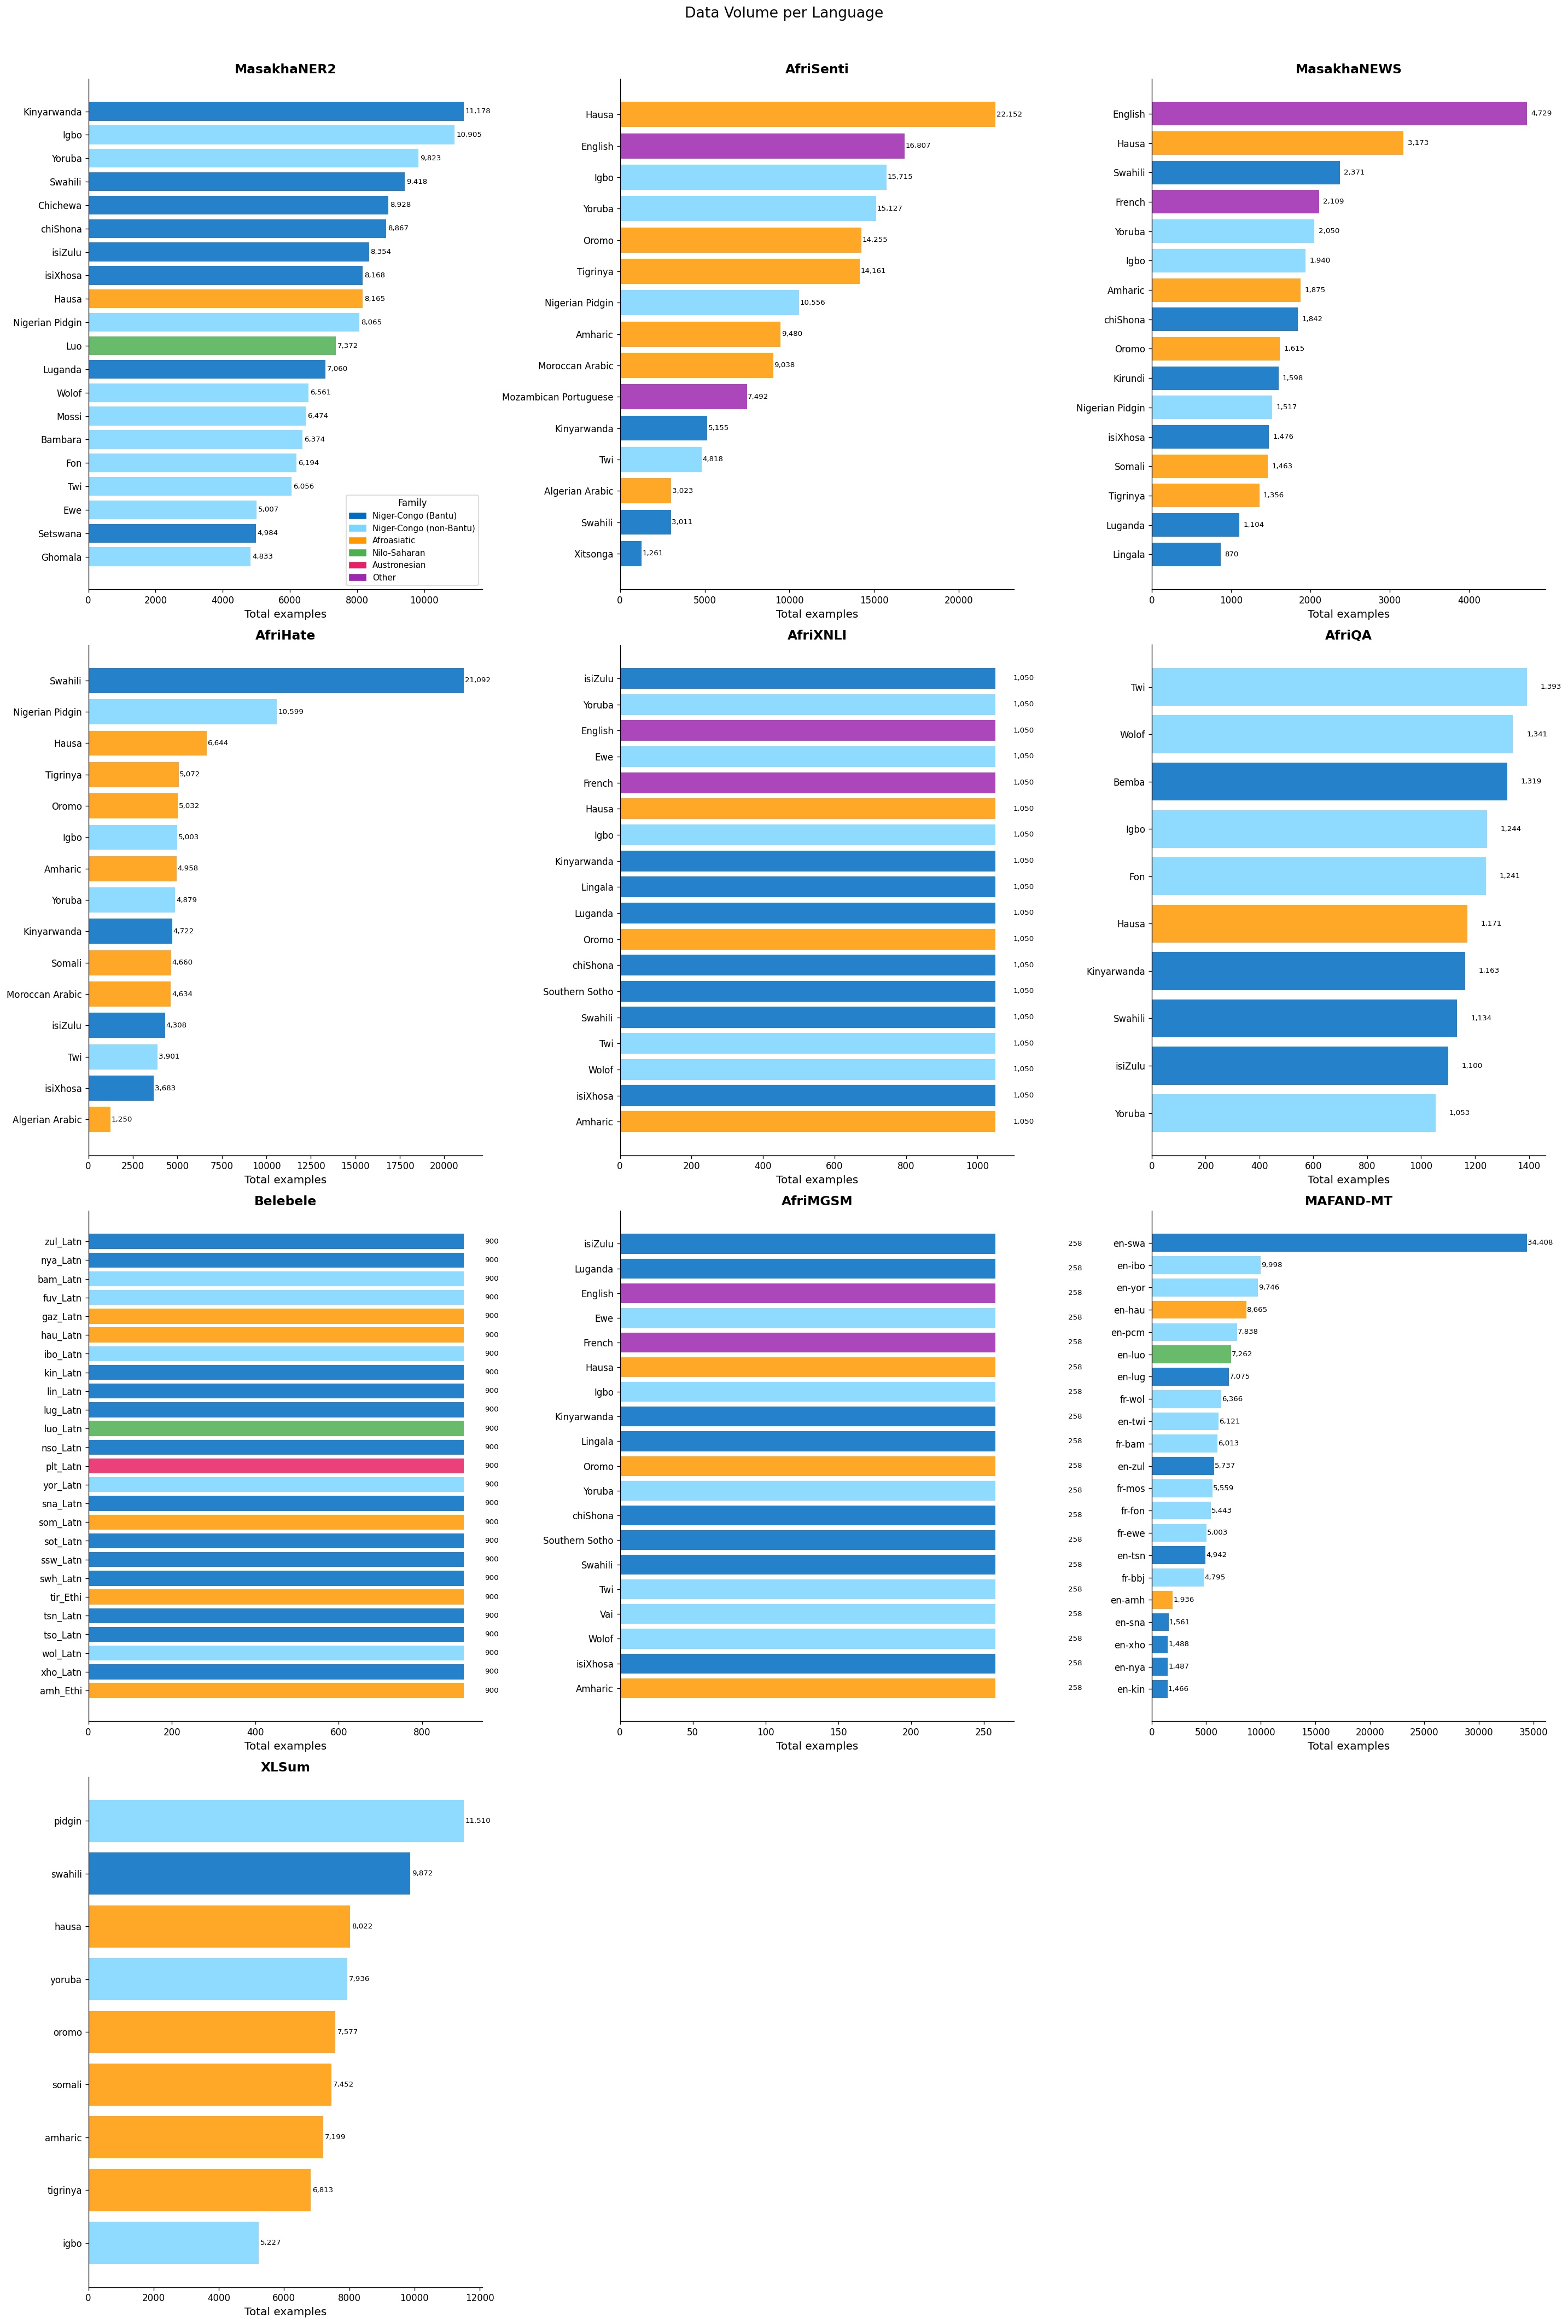

In [77]:
n_ds = len(SUMMARIES)
n_cols = 3
n_rows = (n_ds + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 
    max(6, max(len(df) for df in SUMMARIES.values()) * 0.35) * n_rows))
axes = axes.flatten()

for ax, (ds_name, df) in zip(axes, SUMMARIES.items()):
    df_s = df.sort_values("n_total", ascending=True)
    colors = [FAM_COLORS.get(f, "#999") for f in df_s["family"]]
    ax.barh(df_s["language"], df_s["n_total"], color=colors, alpha=0.85)
    ax.set_xlabel("Total examples")
    ax.set_title(ds_name, fontsize=14, fontweight="bold")
    for i, (v, l) in enumerate(zip(df_s["n_total"], df_s["language"])):
        ax.text(v + 50, i, f"{v:,}", va="center", fontsize=8)

# hide unused subplots
for i in range(n_ds, len(axes)):
    axes[i].set_visible(False)

# shared legend
axes[0].legend(handles=[Patch(color=c, label=f) for f, c in FAM_COLORS.items() if f != "Unknown"],
               loc="lower right", fontsize=9, title="Family")
plt.suptitle("Data Volume per Language", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

**Observations (Analysis 2):**
- Volume imbalance varies a lot across datasets: Belebele and AfriMGSM are perfectly balanced while MAFAND-MT shows a 23.5x ratio between Swahili and Kinyarwanda, or AfriSenti shows a 17.6x ratio between Hausa and Xitsonga (1,261).
- XLSum articles are longer than any other dataset, followed by Belebele passages. Tweet-based datasets (AfriSenti, AfriHate) are the shortest.
- **Decision:** No downsampling. Per-language reporting with weighted aggregation to account for volume differences (RQ3).

### Analysis 3: Language Coverage & Overlap
Which languages appear across multiple tasks? The coverage matrix scales automatically to N datasets.

In [57]:
lang_sets = {
    ds_name: set(normalize_lang_code(l, REGISTRY[ds_name]) for l in data.keys())
    for ds_name, data in ALL_DATA.items()
}
all_langs = sorted(set.union(*lang_sets.values()), key=lambda l: (lfamily(l), lname(l)))

coverage = pd.DataFrame(
    {ds_name: [lang in langs for lang in all_langs] for ds_name, langs in lang_sets.items()},
    index=[f"{lname(l)} ({l})" for l in all_langs]
)
coverage["n_datasets"] = coverage[list(REGISTRY.keys())].sum(axis=1)
coverage["family"] = [lfamily(l) for l in all_langs]

print(f"Total unique languages: {len(all_langs)}")
for ds_name, langs in lang_sets.items():
    print(f"  {ds_name}: {len(langs)} languages")

shared_all = set.intersection(*lang_sets.values())
print(f"\nShared across ALL datasets: {len(shared_all)}")
print(f"    {sorted([lname(l) for l in shared_all])}")

for ds_name, langs in lang_sets.items():
    unique = langs - set.union(*(s for n, s in lang_sets.items() if n != ds_name))
    if unique:
        print(f"  Only in {ds_name}: {sorted([lname(l) for l in unique])}")

display(Markdown("#### Coverage Matrix"))
display(coverage)

Total unique languages: 39
  MasakhaNER2: 20 languages
  AfriSenti: 15 languages
  MasakhaNEWS: 16 languages
  AfriHate: 15 languages
  AfriXNLI: 18 languages
  AfriQA: 10 languages
  Belebele: 25 languages
  AfriMGSM: 19 languages
  MAFAND-MT: 21 languages
  XLSum: 9 languages

Shared across ALL datasets: 4
    ['Hausa', 'Igbo', 'Swahili', 'Yoruba']
  Only in AfriSenti: ['Mozambican Portuguese']
  Only in MasakhaNEWS: ['Kirundi']
  Only in AfriQA: ['Bemba']
  Only in Belebele: ['Fulfulde', 'Malagasy', 'Northern Sotho', 'Swati']
  Only in AfriMGSM: ['Vai']


#### Coverage Matrix

,MasakhaNER2,AfriSenti,MasakhaNEWS,AfriHate,AfriXNLI,AfriQA,Belebele,AfriMGSM,MAFAND-MT,XLSum,n_datasets,family
Algerian Arabic (arq),False,True,False,True,False,False,False,False,False,False,2,Afroasiatic
Amharic (amh),False,True,True,True,True,False,True,True,True,True,8,Afroasiatic
Hausa (hau),True,True,True,True,True,True,True,True,True,True,10,Afroasiatic
Moroccan Arabic (ary),False,True,False,True,False,False,False,False,False,False,2,Afroasiatic
Oromo (orm),False,True,True,True,True,False,True,True,False,True,7,Afroasiatic
Somali (som),False,False,True,True,False,False,True,False,False,True,4,Afroasiatic
Tigrinya (tir),False,True,True,True,False,False,True,False,False,True,5,Afroasiatic
Malagasy (plt),False,False,False,False,False,False,True,False,False,False,1,Austronesian
Bemba (bem),False,False,False,False,False,True,False,False,False,False,1,Niger-Congo (Bantu)
Chichewa (nya),True,False,False,False,False,False,True,False,True,False,3,Niger-Congo (Bantu)


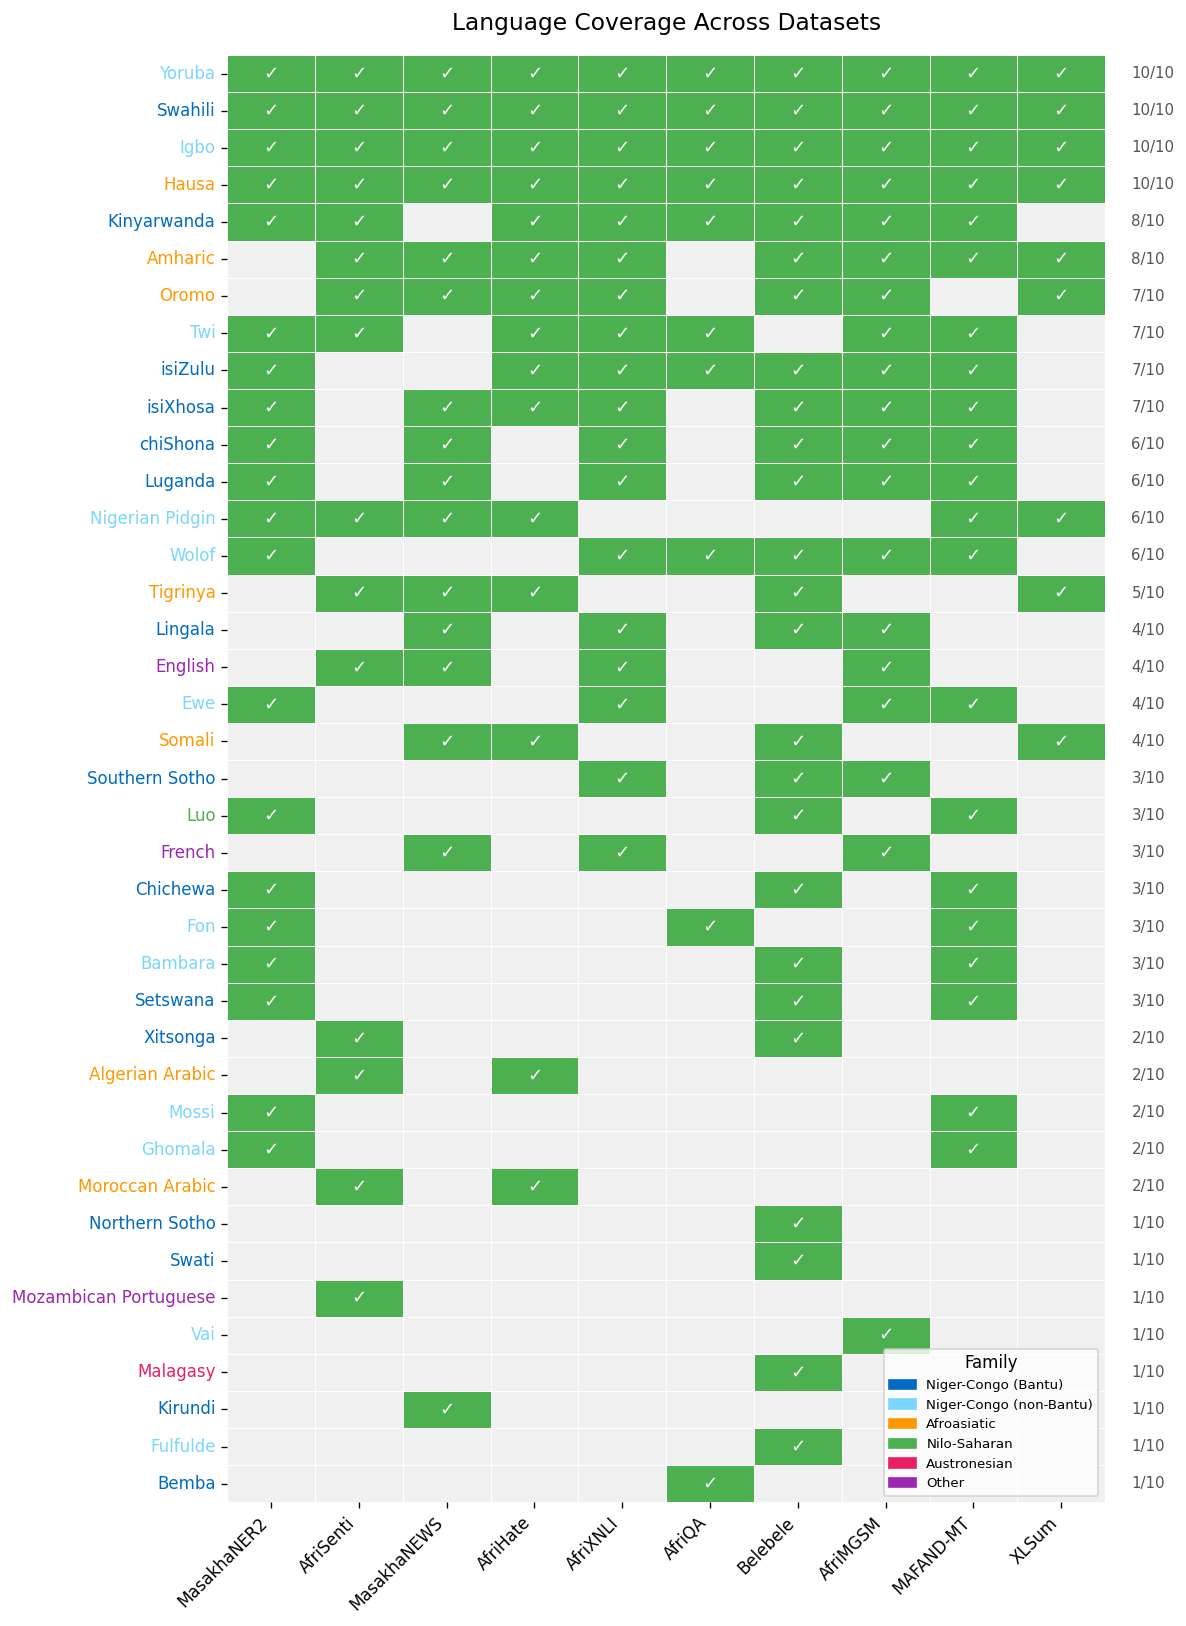

  39 unique languages across 10 datasets.
  4 languages in ALL 10 datasets: ['Hausa', 'Igbo', 'Swahili', 'Yoruba']
  15 languages in 5+ datasets (strong multi-task candidates)
  26 languages in 3+ datasets
  8 languages in only 1 dataset


In [61]:
# build boolean matrix: languages x datasets
coverage_matrix = pd.DataFrame(
    {ds_name: {lname(l): l in langs for l in all_langs}
     for ds_name, langs in lang_sets.items()}
)
coverage_matrix = coverage_matrix.sort_index()

# add n_datasets column for sorting
coverage_matrix["n_datasets"] = coverage_matrix.sum(axis=1)
coverage_matrix = coverage_matrix.sort_values("n_datasets", ascending=False)
n_ds_col = coverage_matrix.pop("n_datasets")

fig, ax = plt.subplots(figsize=(10, max(8, len(all_langs) * 0.35)))
sns.heatmap(coverage_matrix.astype(int), ax=ax,
            cmap=["#f0f0f0", "#4CAF50"], cbar=False,
            linewidths=0.5, linecolor="white",
            annot=coverage_matrix.replace({True: "✓", False: ""}),
            fmt="s", annot_kws={"fontsize": 11})

# color y-labels by family
for lbl in ax.get_yticklabels():
    lang_code = [c for c in all_langs if lname(c) == lbl.get_text()]
    if lang_code:
        lbl.set_color(FAM_COLORS.get(lfamily(lang_code[0]), "#333"))

# x-axis labels at 45 degrees
ax.tick_params(axis="x", rotation=45)
ax.set_xticklabels(ax.get_xticklabels(), ha="right")

# add dataset count on the right
for i, (lang, count) in enumerate(n_ds_col.items()):
    ax.text(len(lang_sets) + 0.3, i + 0.5, f"{int(count)}/{len(REGISTRY)}",
            va="center", fontsize=9, color="#555")

ax.set_title("Language Coverage Across Datasets", fontsize=14, pad=15)
ax.set_xlabel("")
ax.set_ylabel("")

# family legend
fam_patches = [Patch(color=c, label=f) for f, c in FAM_COLORS.items() if f != "Unknown"]
ax.legend(handles=fam_patches, loc="lower right", fontsize=8, title="Family")

plt.tight_layout()
plt.show()

# summary stats
n_total = len(REGISTRY)
n_all = int((n_ds_col == n_total).sum())
n_half = int((n_ds_col >= n_total // 2).sum())
n_4plus = int((n_ds_col >= 4).sum())
n_3plus = int((n_ds_col >= 3).sum())

print(f"  {len(all_langs)} unique languages across {n_total} datasets.")
print(f"  {n_all} languages in ALL {n_total} datasets: {sorted([l for l, c in n_ds_col.items() if c == n_total])}")
print(f"  {n_half} languages in {n_total//2}+ datasets (strong multi-task candidates)")
print(f"  {n_3plus} languages in 3+ datasets")
print(f"  {int((n_ds_col == 1).sum())} languages in only 1 dataset")

**Observations (Analysis 3):**
- 4 languages appear in all 10 datasets: **Yoruba, Swahili, Igbo, Hausa** — these are the strongest candidates for cross-task bias analysis (RQ1).
- 8 languages appear in more than 7 datasets, covering both Niger-Congo and Afroasiatic families.
- 10 languages appear in only 1 dataset. These cannot be evaluated cross-task but still contribute to language diversity within individual tasks.
- **Implication for RQ1:** Cross-language evaluation is most reliable for the top 8 languages. For the others, findings will be task-specific.

### Analysis 4: Label / Class Balance
Class balance is one of the most important default analyses. A generic function handles both token-level (NER) and text-level (sentiment) labels across all datasets.

In [66]:
def get_label_distribution(ds_name, cfg, data, split="train"):
    """Generic label distribution for any task type with a label field"""
    records = []
    lf = cfg["label_field"]
    if lf is None: return pd.DataFrame()
    
    for lang, ds in data.items():
        sp = split if split in ds else default_split(ds)
        if sp not in ds: continue
        raw = ds[sp][lf]
        flat = [t for seq in raw for t in seq] if cfg["task_type"] == "token_classification" else raw
        counter = Counter(flat)
        total = sum(counter.values())
        for label_val, count in counter.items():
            if cfg.get("_label_is_string", False):
                label_name = label_val
            elif cfg.get("label_map"):
                label_name = cfg["label_map"].get(label_val, str(label_val))
            else:
                label_name = str(label_val)
            records.append({"dataset": ds_name, "lang_code": lang,
                            "language": lname(lang), "label": label_name,
                            "count": count, "pct": count/total*100})
    return pd.DataFrame(records)

# only compute label distribution for tasks where it makes sense
LABEL_DIST_TASKS = ["token_classification", "text_classification", "nli"]

LABEL_DISTS = {}
for ds_name, cfg in REGISTRY.items():
    if cfg["task_type"] not in LABEL_DIST_TASKS:
        continue
    df = get_label_distribution(ds_name, cfg, ALL_DATA[ds_name])
    if not df.empty:
        LABEL_DISTS[ds_name] = df

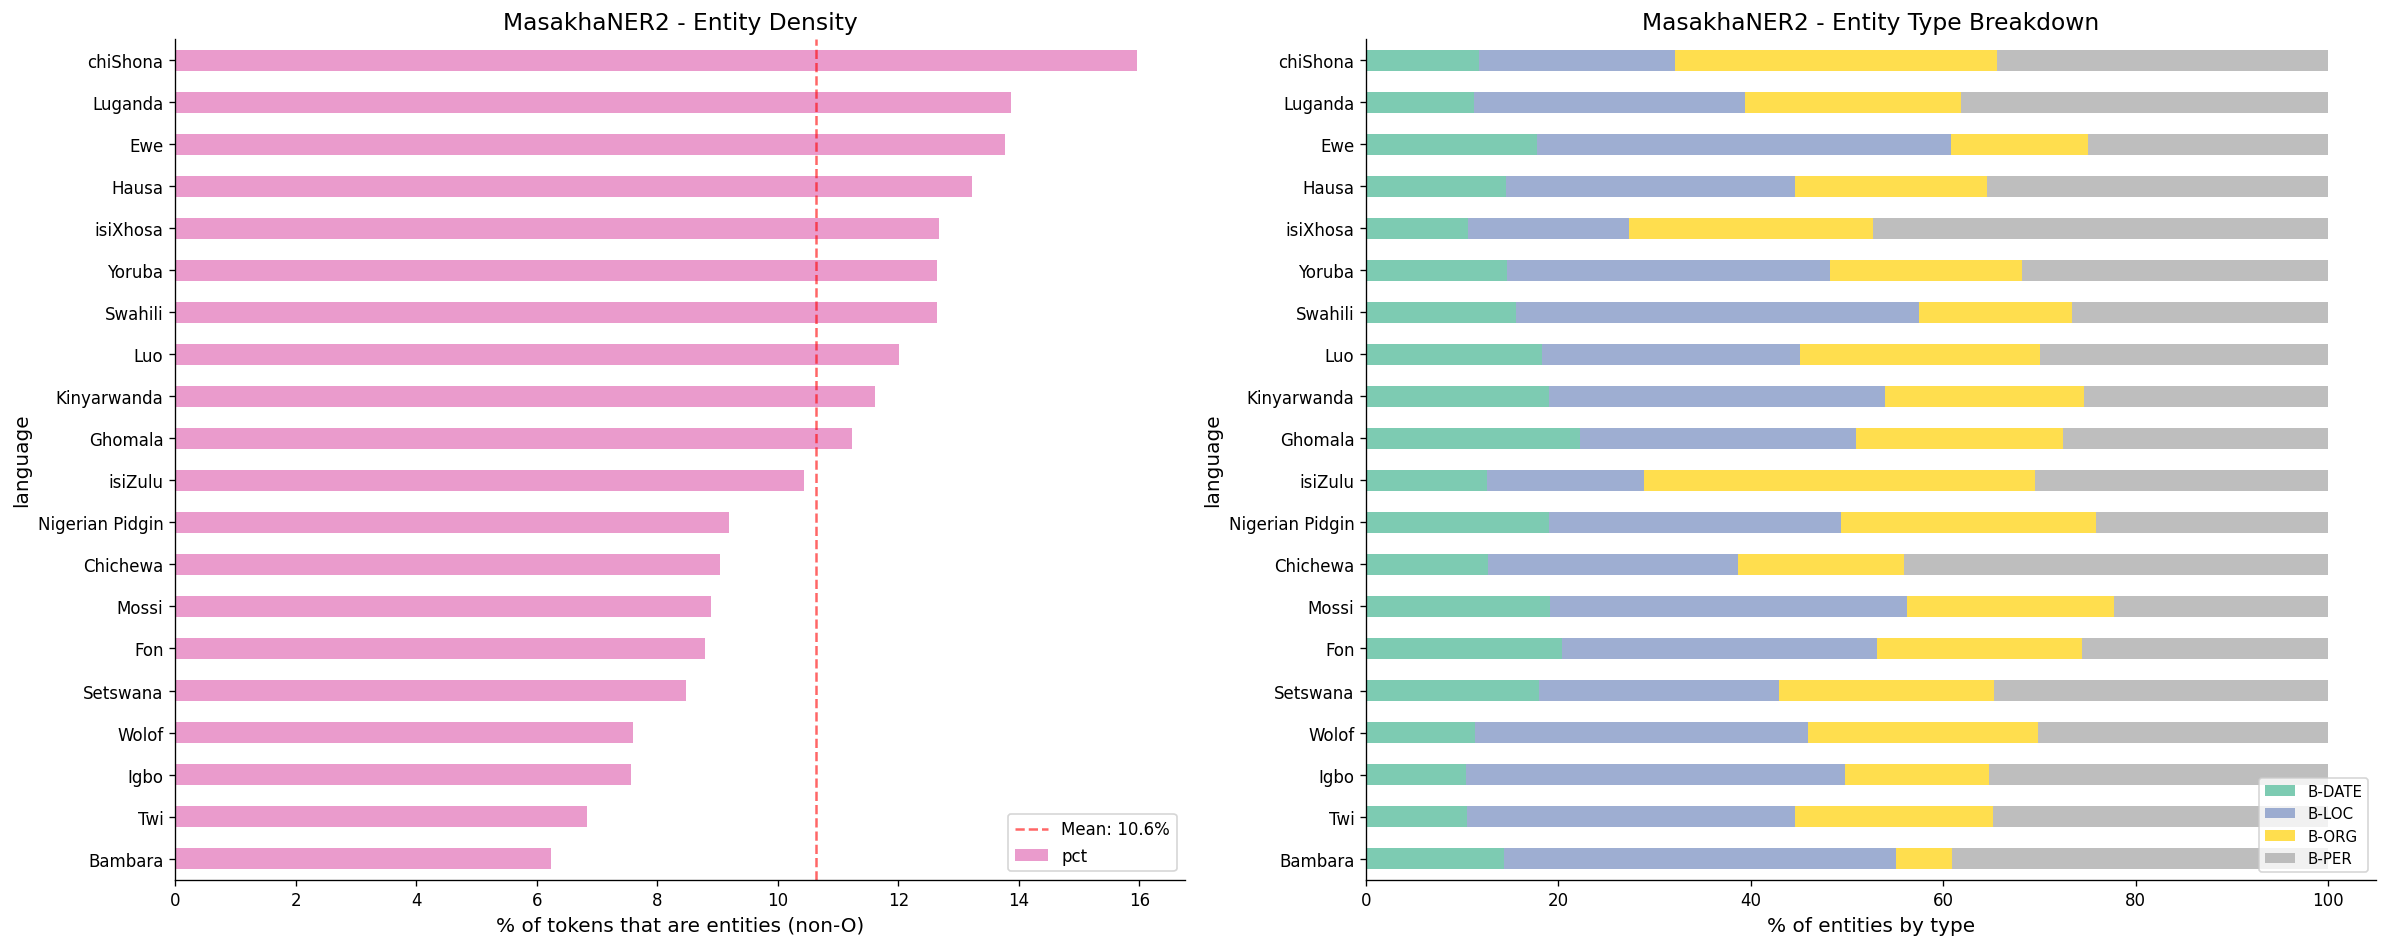

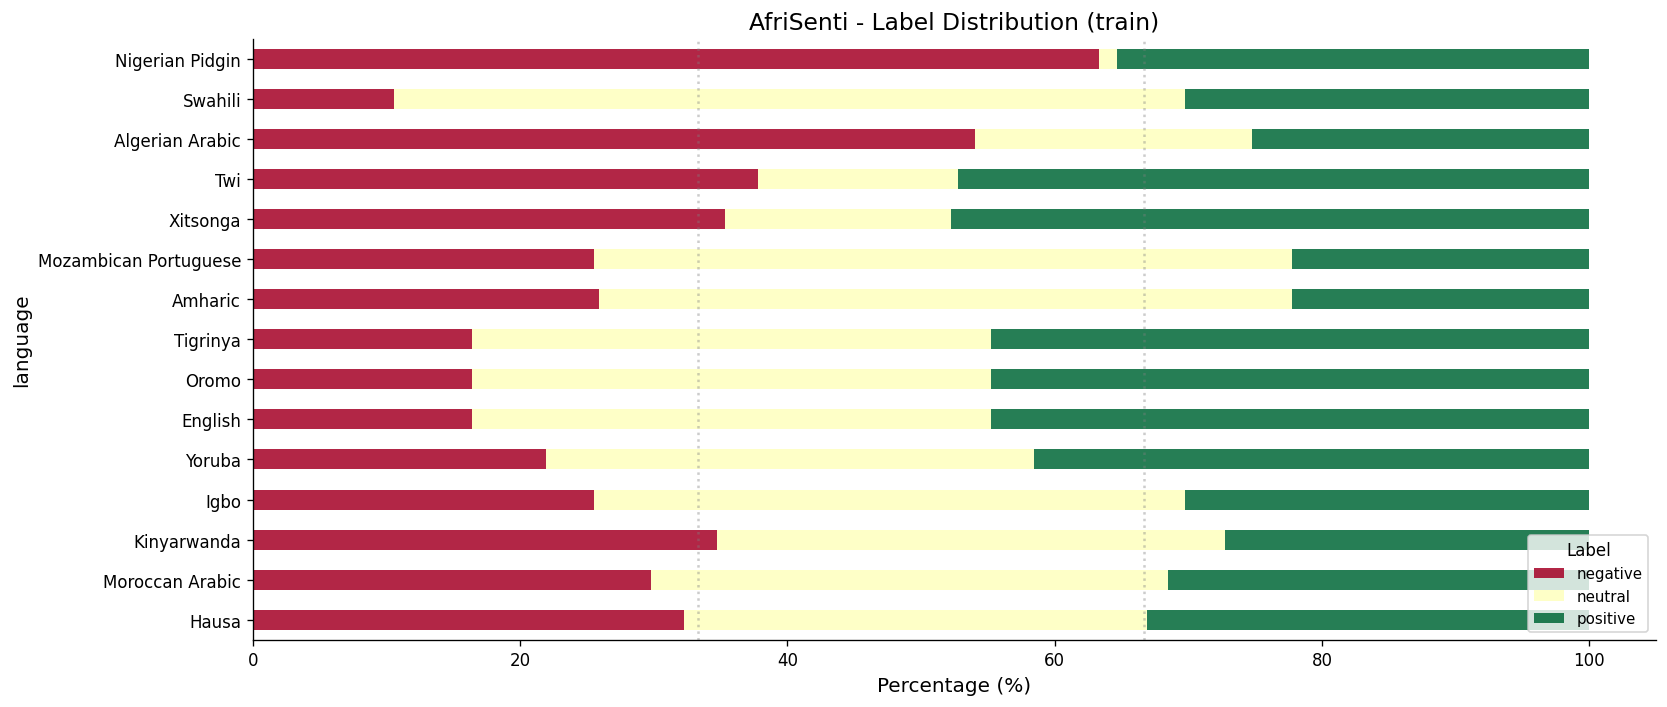

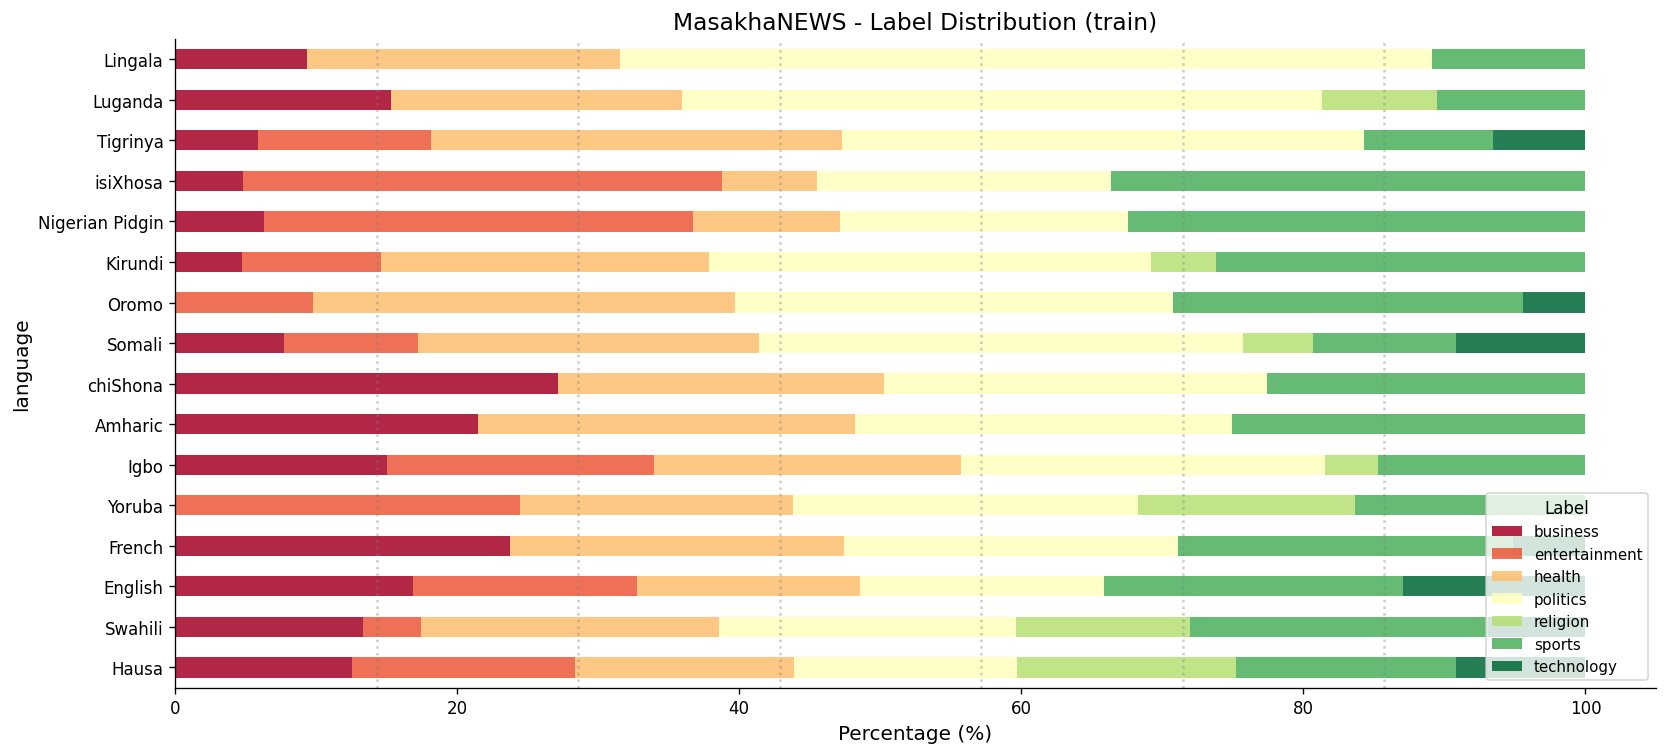

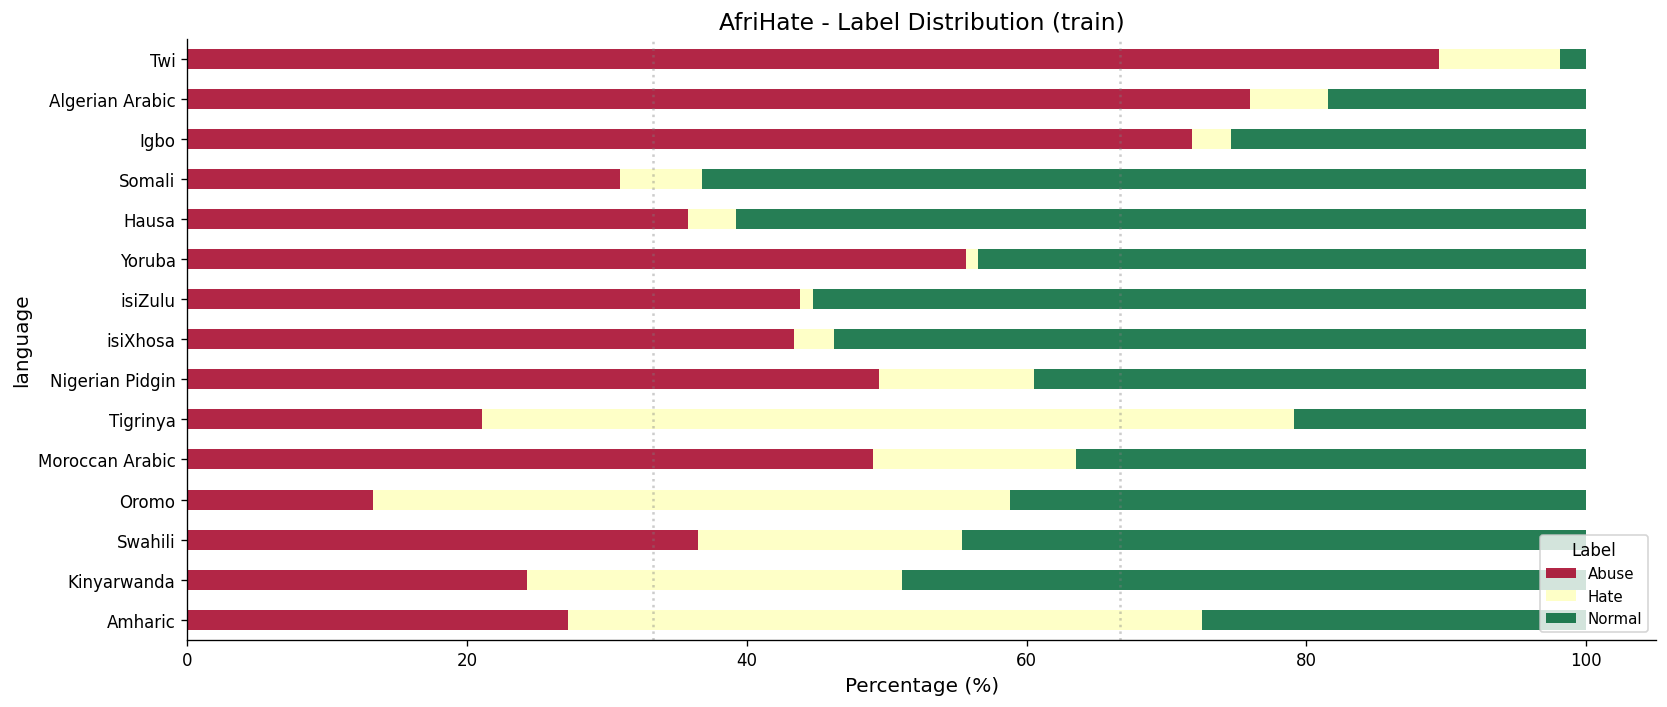

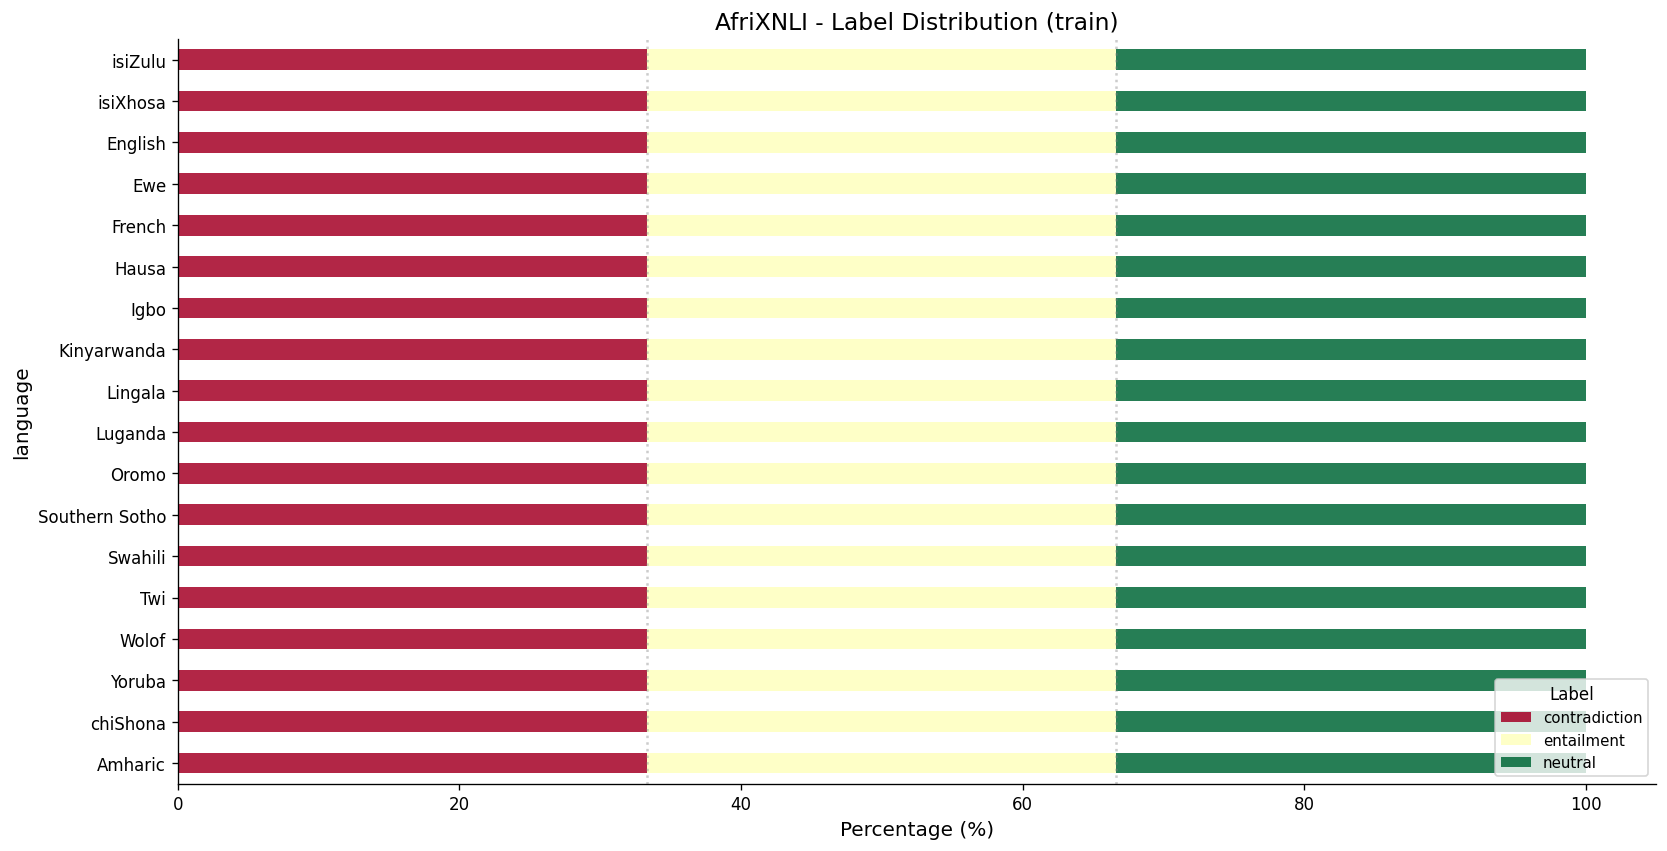

MasakhaNER2: Entity density 6.2% to 16.0%
MasakhaNER2: Entity types (overall): {'B-PER': 50445, 'B-LOC': 48129, 'B-ORG': 34033, 'B-DATE': 23098}
AfriSenti: Most imbalanced = Nigerian Pidgin (spread: 61.9pp)
MasakhaNEWS: Most imbalanced = Lingala (spread: 48.2pp)
AfriHate: Most imbalanced = Twi (spread: 87.6pp)
AfriXNLI: Most imbalanced = Amharic (spread: 0.0pp)


In [67]:
for ds_name, df in LABEL_DISTS.items():
    cfg = REGISTRY[ds_name]
    
    if cfg["task_type"] == "token_classification":
        fig, axes = plt.subplots(1, 2, figsize=(20, max(5, df["language"].nunique()*0.4)))
        
        # left: entity density
        ax = axes[0]
        entity_pct = (df[df["label"] != "O"]
                      .groupby("language")["pct"].sum()
                      .sort_values(ascending=True))
        entity_pct.plot(kind="barh", ax=ax, color=PAL[3], alpha=0.85)
        ax.axvline(entity_pct.mean(), color="red", ls="--", alpha=0.6,
                   label=f"Mean: {entity_pct.mean():.1f}%")
        ax.set_xlabel("% of tokens that are entities (non-O)")
        ax.set_title(f"{ds_name} - Entity Density")
        ax.legend()
        
        # right: entity type breakdown (B-tags only)
        ax = axes[1]
        b_tags = df[df["label"].str.startswith("B-")]
        pivot = b_tags.pivot_table(index="language", columns="label",
                                    values="count", fill_value=0)
        pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
        pivot_pct = pivot_pct.loc[entity_pct.index]  # same order
        pivot_pct.plot(kind="barh", stacked=True, ax=ax, colormap="Set2", alpha=0.85)
        ax.set_xlabel("% of entities by type")
        ax.set_title(f"{ds_name} - Entity Type Breakdown")
        ax.legend(loc="lower right", fontsize=9)
        
    else:
        fig, ax = plt.subplots(figsize=(14, max(5, df["language"].nunique()*0.4)))
        pivot = df.pivot_table(index="language", columns="label", values="pct", fill_value=0)
        pivot["_imb"] = pivot.max(axis=1) - pivot.min(axis=1)
        pivot = pivot.sort_values("_imb", ascending=True).drop(columns="_imb")
        pivot.plot(kind="barh", stacked=True, ax=ax, colormap="RdYlGn", alpha=0.85)
        n_classes = df["label"].nunique()
        for k in range(1, n_classes):
            ax.axvline(100*k/n_classes, color="gray", ls=":", alpha=0.4)
        ax.set_xlabel("Percentage (%)")
        ax.set_xlim(0, 105)
        ax.legend(title="Label", loc="lower right", fontsize=9)
        ax.set_title(f"{ds_name} - Label Distribution (train)")

    plt.tight_layout()
    plt.show()

for ds_name, df in LABEL_DISTS.items():
    cfg = REGISTRY[ds_name]
    if cfg["task_type"] == "token_classification":
        ent = df[df["label"] != "O"].groupby("language")["pct"].sum()
        print(f"{ds_name}: Entity density {ent.min():.1f}% to {ent.max():.1f}%")
        b_tags = df[df["label"].str.startswith("B-")]
        type_totals = b_tags.groupby("label")["count"].sum().sort_values(ascending=False)
        print(f"{ds_name}: Entity types (overall): {dict(type_totals)}")
    else:
        imb = df.groupby("language")["pct"].agg(lambda x: x.max()-x.min())
        print(f"{ds_name}: Most imbalanced = {imb.idxmax()} (spread: {imb.max():.1f}pp)")

**Observations (Analysis 4):**
- **AfriXNLI** is perfectly balanced by design and means any judge bias won't be affected by label imbalance.
- **AfriHate** is the most imbalanced: Twi has 87.6pp spread, while Amharic is relatively balanced. This language-dependent imbalance is itself a bias signal (RQ2) that a judge may learn to predict the majority class differently per language.
- **AfriSenti** shows cultural patterns: Nigerian Pidgin is really positive, while Algerian Arabic is heavily negative. These indicates cultural sentiment differences, not annotation noise.
- **MasakhaNEWS** topic distributions could reflect media priorities: Lingala news is centered in sports, while English/Hausa are more evenly distributed.
- **MasakhaNER2** entity density ranges from 6.2% to 16.0%, with PER (person) being the most frequent entity type overall.

### Analysis 5: Text Length Distributions
Text length affects LLM judge behavior (position bias, truncation). Also helps identify outliers.

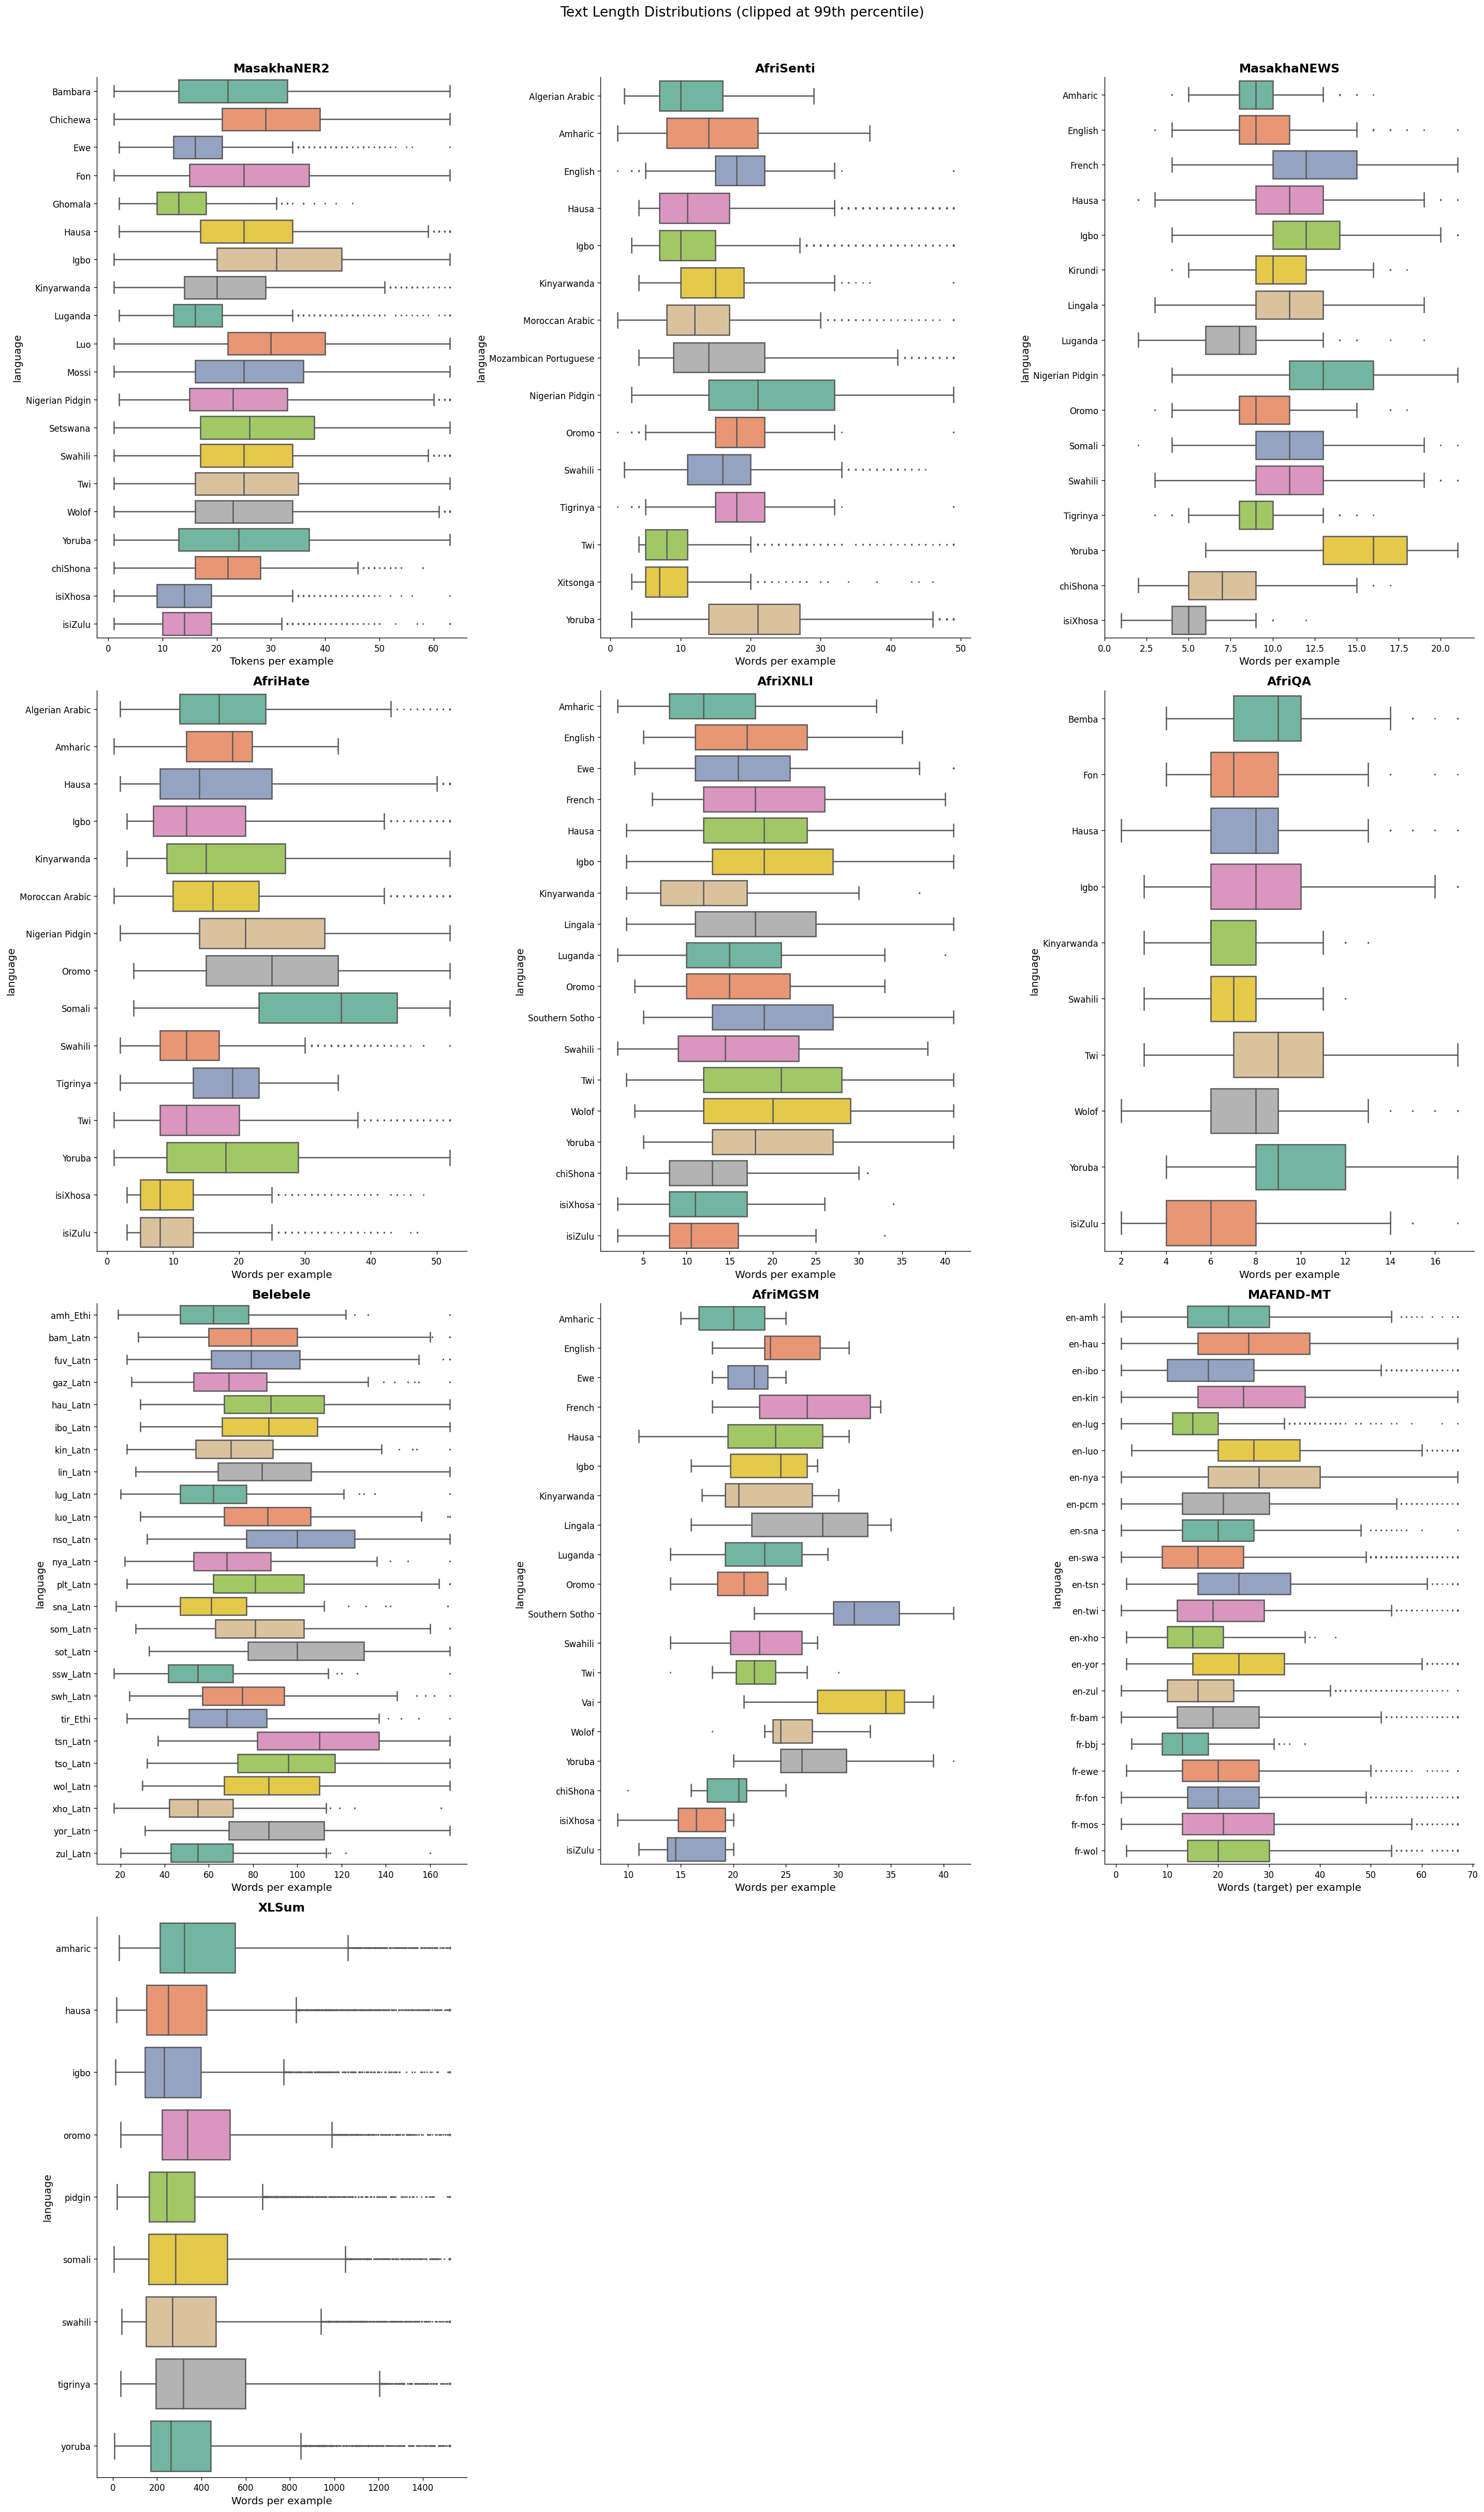

Outliers clipped at 99th percentile for readability — not removed from data.


In [78]:
n_ds = len(REGISTRY)
n_cols = 3
n_rows = (n_ds + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols,
    max(6, max(len(d) for d in ALL_DATA.values()) * 0.4) * n_rows))
axes = axes.flatten()

for ax, (ds_name, cfg) in zip(axes, REGISTRY.items()):
    data = ALL_DATA[ds_name]
    records = []
    for lang, ds in data.items():
        sp = default_split(ds)
        vals = ds[sp][cfg["text_field"]]
        for v in vals:
            if isinstance(v, list):
                length = len(v)
            elif isinstance(v, dict):  # translation pairs
                target_key = list(v.keys())[-1]
                length = len(str(v[target_key]).split())
            else:
                length = len(str(v).split())
            records.append({"language": lname(lang), "length": length})

    len_df = pd.DataFrame(records)

    # clip outliers at 99th percentile so boxplots are readable
    p99 = len_df["length"].quantile(0.99)
    len_df["length"] = len_df["length"].clip(upper=p99)

    if isinstance(vals[0], list):
        unit = "tokens"
    elif isinstance(vals[0], dict):
        unit = "words (target)"
    else:
        unit = "words"

    sns.boxplot(data=len_df, y="language", x="length", ax=ax,
                palette="Set2", fliersize=1,
                order=sorted(len_df["language"].unique()))
    ax.set_xlabel(f"{unit.capitalize()} per example")
    ax.set_title(ds_name, fontsize=14, fontweight="bold")

# hide unused subplots
for i in range(n_ds, len(axes)):
    axes[i].set_visible(False)

plt.suptitle("Text Length Distributions (clipped at 99th percentile)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

print("Outliers clipped at 99th percentile for readability — not removed from data.")

**Observations (Analysis 5):**
- Text length varies across languages within the same dataset. In AfriXNLI, Swahili premises are longer than Amharic ones. In MAFAND-MT, French-target translations are shorter than English-targets. These differences are potential sources of **length bias** in LLM judges (RQ2).
- XLSum shows the widest variance: article length ranges from 200 to more than 1500 words, meaning the judge will need to handle very different input sizes.
- **Implication for RQ2:** Length-controlled evaluation subsets may be needed to isolate length bias from content effects.

### Analysis 6: Data Quality & Anomaly Detection
Generic quality checks: empty texts, annotation mismatches, duplicates, very short entries. All decisions logged.

In [79]:
print("=" * 70)
print("DATA QUALITY AUDIT")
print("=" * 70)

for ds_name, cfg in REGISTRY.items():
    data = ALL_DATA[ds_name]
    print(f"\n--- {ds_name} ---")
    issues = {"empty": 0, "very_short": 0, "duplicates": 0, "tag_mismatch": 0, "total": 0}
    details = []
    
    for lang, ds in data.items():
        for sp in ["train", "validation", "test"]:
            if sp not in ds: continue
            issues["total"] += len(ds[sp])
            texts = ds[sp][cfg["text_field"]]
            
            for i, t in enumerate(texts):
                length = len(t) if isinstance(t, list) else len(str(t).strip())
                if length == 0:
                    issues["empty"] += 1
                    details.append(f"  EMPTY: {lang}/{sp}/idx={i}")
                elif not isinstance(t, list) and length < 3:
                    issues["very_short"] += 1
            
            if cfg["task_type"] == "token_classification" and cfg["label_field"]:
                labels = ds[sp][cfg["label_field"]]
                for i, (t, l) in enumerate(zip(texts, labels)):
                    if len(t) != len(l):
                        issues["tag_mismatch"] += 1
                        details.append(f"  MISMATCH: {lang}/{sp}/idx={i}")
            
            # check duplicates (skip tasks where text repetition is by design)
            skip_dup_tasks = ["nli", "reading_comprehension"]
            if not isinstance(texts[0], (list, dict)) and cfg["task_type"] not in skip_dup_tasks:
                n_dup = len(texts) - len(set(texts))
                if n_dup > 0:
                    issues["duplicates"] += n_dup
                    details.append(f"  DUPLICATES: {lang}/{sp} -> {n_dup}")
    
    print(f"  Checked:        {issues['total']:,}")
    print(f"  Empty:          {issues['empty']}")
    print(f"  Very short:     {issues['very_short']}")
    print(f"  Tag mismatches: {issues['tag_mismatch']}")
    print(f"  Duplicates:     {issues['duplicates']}")
    if details:
        for d in details: print(d)
    else:
        print("  No issues found.")

DATA QUALITY AUDIT

--- MasakhaNER2 ---
  Checked:        152,786
  Empty:          0
  Very short:     0
  Tag mismatches: 0
  Duplicates:     0
  No issues found.

--- AfriSenti ---
  Checked:        152,051
  Empty:          0
  Very short:     9
  Tag mismatches: 0
  Duplicates:     1164
  DUPLICATES: amh/train -> 1
  DUPLICATES: arq/train -> 10
  DUPLICATES: arq/validation -> 1
  DUPLICATES: ary/train -> 20
  DUPLICATES: kin/train -> 43
  DUPLICATES: kin/validation -> 5
  DUPLICATES: orm/test -> 69
  DUPLICATES: pcm/train -> 512
  DUPLICATES: pcm/validation -> 34
  DUPLICATES: por/train -> 80
  DUPLICATES: por/validation -> 2
  DUPLICATES: swa/train -> 8
  DUPLICATES: twi/train -> 376
  DUPLICATES: twi/validation -> 3

--- MasakhaNEWS ---
  Checked:        31,088
  Empty:          0
  Very short:     0
  Tag mismatches: 0
  Duplicates:     151
  DUPLICATES: amh/train -> 68
  DUPLICATES: amh/validation -> 3
  DUPLICATES: amh/test -> 3
  DUPLICATES: eng/train -> 6
  DUPLICATES: eng/

**Observations (Analysis 6):**
- No critical quality issues found across all 10 datasets. Zero empty texts in 8/10 datasets, zero tag mismatches in NER.
- **AfriHate** has the most duplicates. These likely represent retweets of viral hateful content (expected for tweet-based datasets).
- **AfriSenti** duplicates are concentrated, again likely retweets.
- **Decision:** Data kept as-is. Duplicates are natural for tweet corpus and removing them would alter the label distribution.

### Analysis 7: Language Family Analysis
Do linguistic families show different data characteristics? Relevant for detecting systematic bias (RQ1, RQ2).

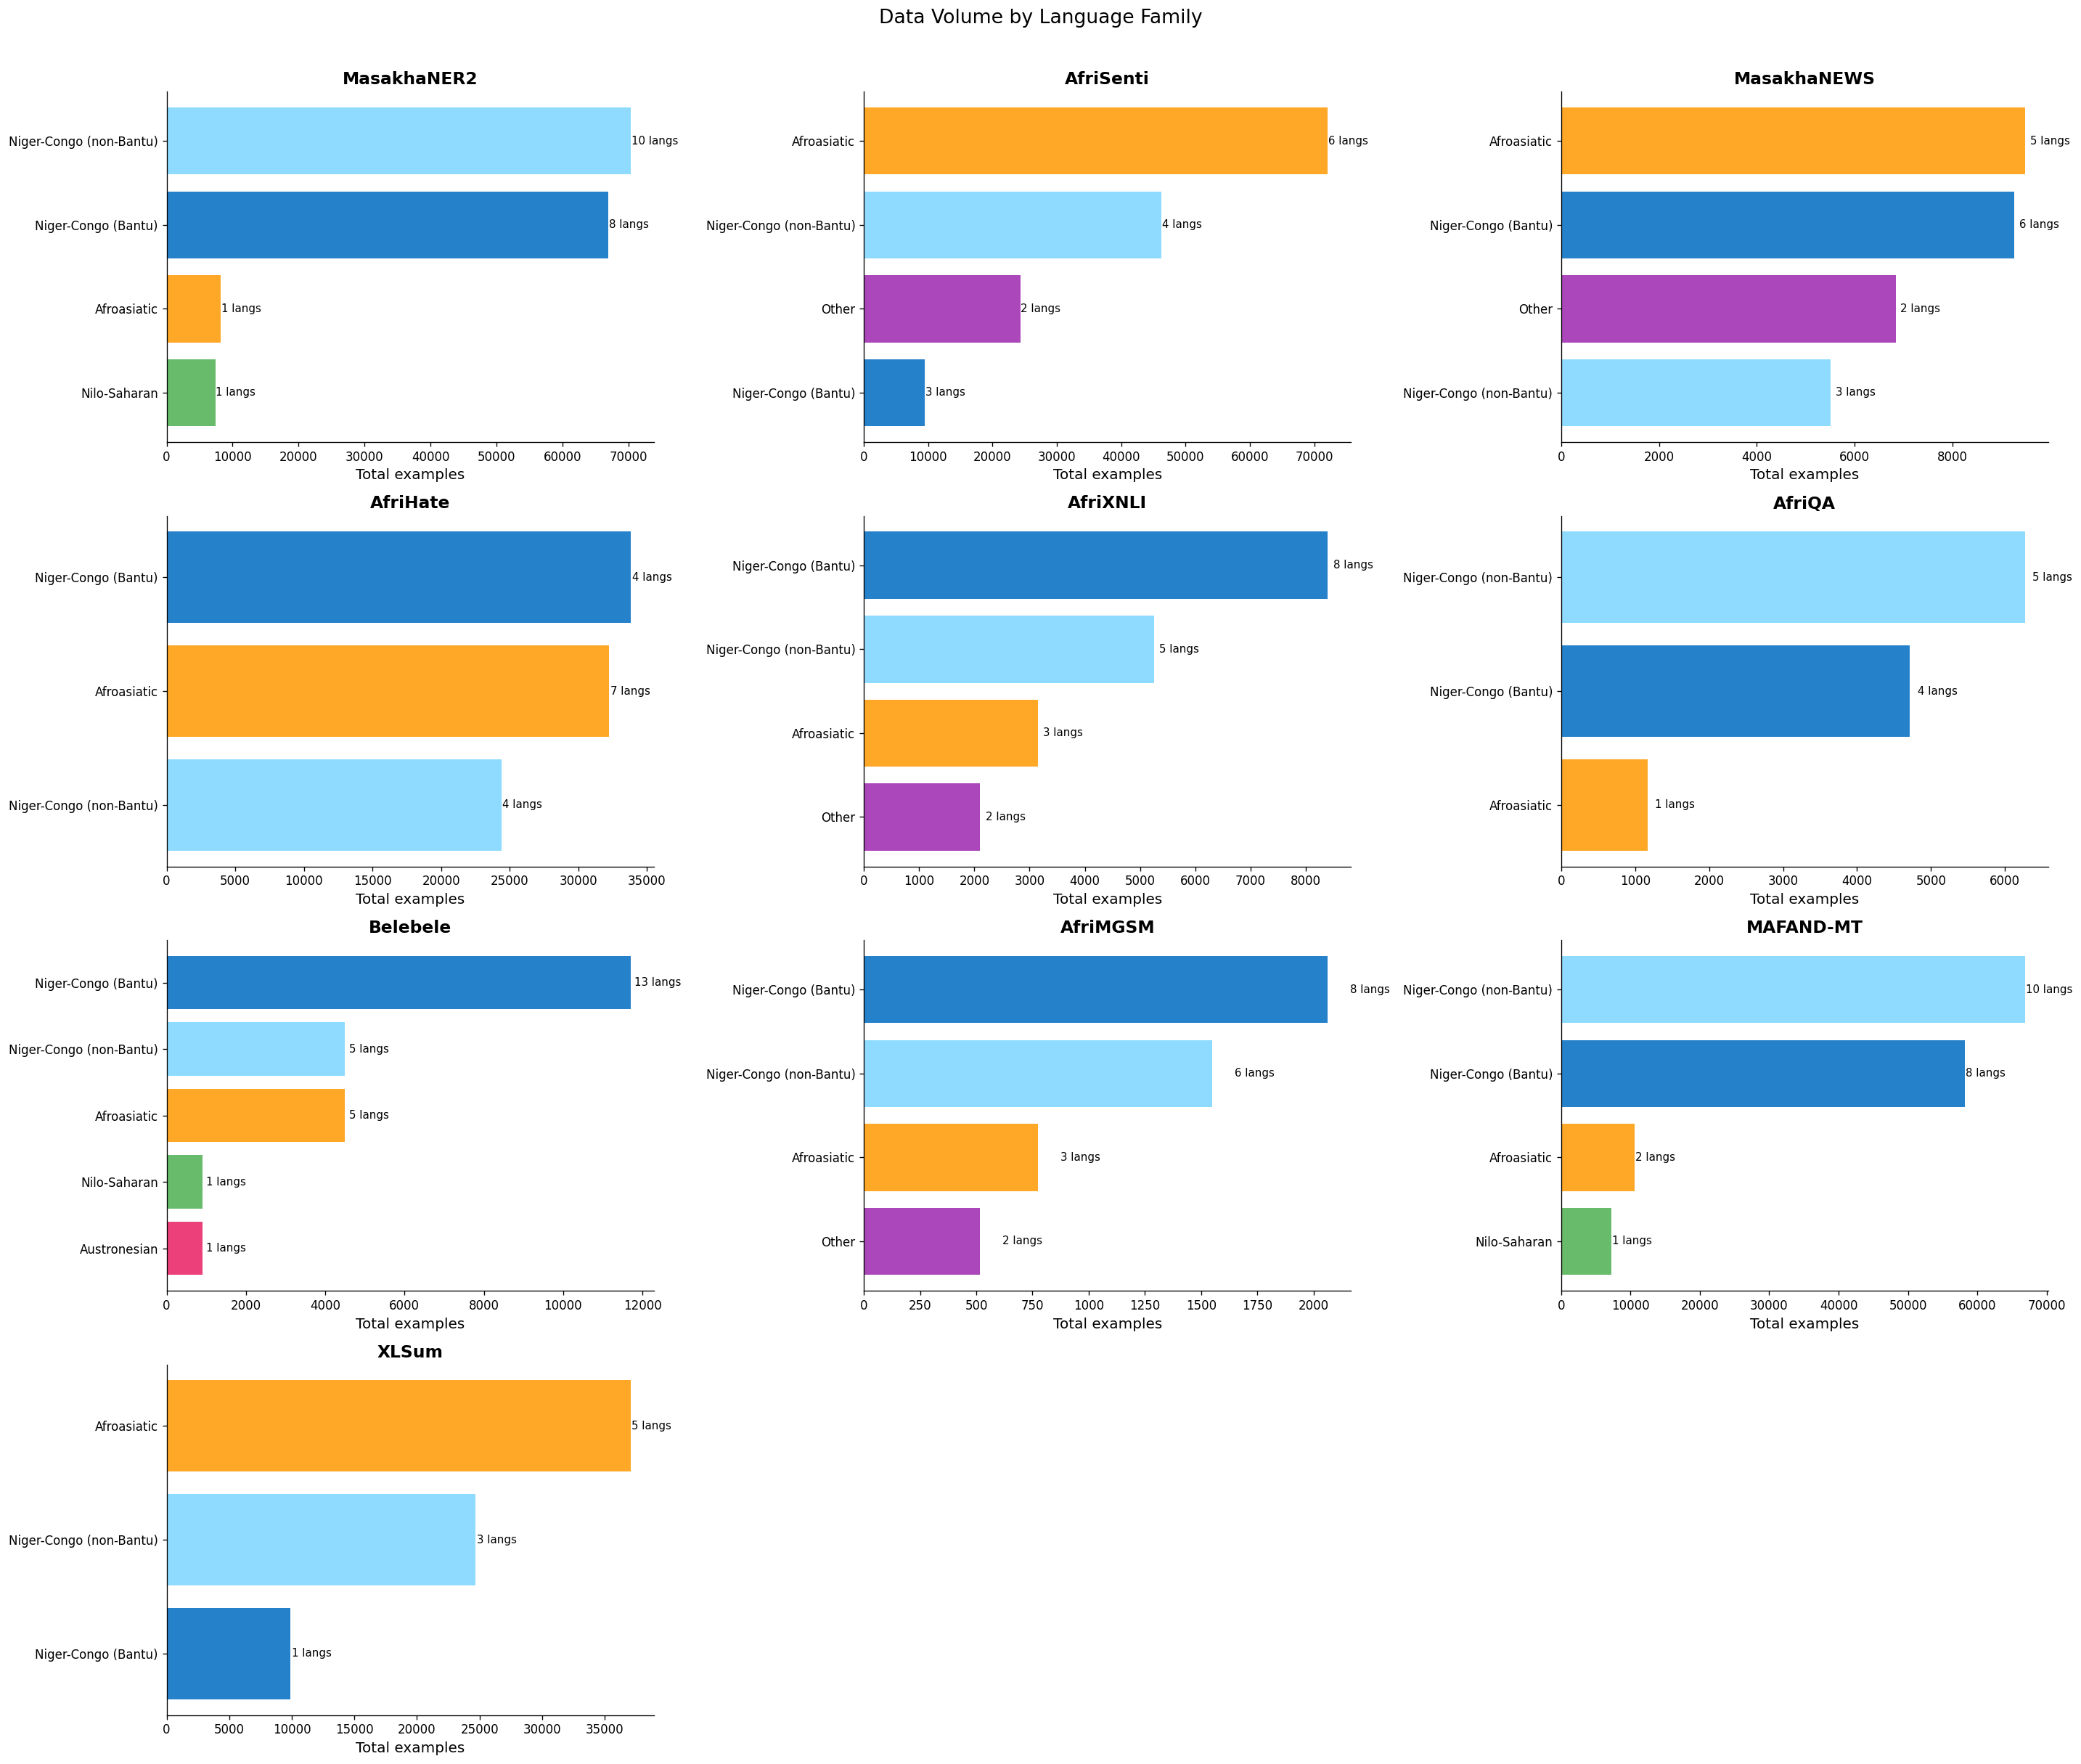

In [80]:
n_ds = len(SUMMARIES)
n_cols = 3
n_rows = (n_ds + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 5*n_rows))
axes = axes.flatten()

for ax, (ds_name, df) in zip(axes, SUMMARIES.items()):
    fam = df.groupby("family").agg(
        n_langs=("language","nunique"), total=("n_total","sum")
    ).sort_values("total", ascending=True)
    colors = [FAM_COLORS.get(f, "#999") for f in fam.index]
    bars = ax.barh(fam.index, fam["total"], color=colors, alpha=0.85)
    ax.set_xlabel("Total examples")
    ax.set_title(ds_name, fontsize=14, fontweight="bold")
    for bar, (_, row) in zip(bars, fam.iterrows()):
        ax.text(bar.get_width()+100, bar.get_y()+bar.get_height()/2,
                f"{int(row['n_langs'])} langs", va="center", fontsize=9)

for i in range(n_ds, len(axes)):
    axes[i].set_visible(False)

plt.suptitle("Data Volume by Language Family", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

**Observations (Analysis 7):**
- **Niger-Congo (Bantu)** has the most language representation (up to 13 languages in Belebele) and the most total data volume in most datasets.
- **Afroasiatic** languages dominate AfriHate (7 languages with the most data), AfriSenti (6 languages), and XLSum (5 languages); reflecting the availability of different scripts.
- **Nilo-Saharan** is represented only by Luo in 3 datasets and **Austronesian** only by Malagasy in Belebele; these families are underrepresented.
- **Implication for RQ2:** Any bias analysis by language family will have strong statistical power for Niger-Congo and Afroasiatic.

### Analysis 8: Baseline Estimation
Majority-class baselines set the performance floor. For AfriSenti, comparable to published SemEval-2023 scores.

In [73]:
print("=" * 70)
print("MAJORITY-CLASS BASELINES (test split)")
print("=" * 70)

BASELINES = {}
BASELINE_TASKS = ["token_classification", "text_classification", "nli"]
for ds_name, cfg in REGISTRY.items():
    if cfg["label_field"] is None: continue
    if cfg["task_type"] not in BASELINE_TASKS: continue
    data = ALL_DATA[ds_name]
    rows = []
    
    for lang, ds in sorted(data.items()):
        if "test" not in ds: continue
        raw = ds["test"][cfg["label_field"]]
        
        if cfg["task_type"] == "token_classification":
            flat = [t for seq in raw for t in seq]
            counter = Counter(flat)
            maj_val = counter.most_common(1)[0][0]
            maj_acc = counter[maj_val] / len(flat) * 100
            maj_label = cfg["label_map"].get(maj_val, str(maj_val)) if cfg.get("label_map") else str(maj_val)
            rows.append({"language": lname(lang), "majority_class": maj_label,
                         "token_acc_%": round(maj_acc,1), "entity_f1": 0.0})
        else:
            counter = Counter(raw)
            maj_val, maj_count = counter.most_common(1)[0]
            maj_acc = maj_count / len(raw) * 100
            if cfg.get("_label_is_string", False):
                maj_label = maj_val
            elif cfg.get("label_map"):
                maj_label = cfg["label_map"].get(maj_val, str(maj_val))
            else:
                maj_label = str(maj_val)
            rows.append({"language": lname(lang), "majority_class": maj_label,
                         "accuracy_%": round(maj_acc,1), "n_test": len(raw)})
    
    bl_df = pd.DataFrame(rows)
    BASELINES[ds_name] = bl_df
    display(Markdown(f"#### {ds_name}"))
    display(bl_df)
    

    if "accuracy_%" in bl_df.columns:
        print(f"  Mean: {bl_df['accuracy_%'].mean():.1f}% | "
              f"Range: {bl_df['accuracy_%'].min():.1f}%-{bl_df['accuracy_%'].max():.1f}%")
    if "token_acc_%" in bl_df.columns:
        print(f"  Mean token acc: {bl_df['token_acc_%'].mean():.1f}% (entity F1 = 0% for all-O)")
    print()

MAJORITY-CLASS BASELINES (test split)


#### MasakhaNER2

,language,majority_class,token_acc_%,entity_f1
0,Bambara,O,93.0,0.0
1,Ghomala,O,87.3,0.0
2,Ewe,O,82.1,0.0
3,Fon,O,92.4,0.0
4,Hausa,O,81.6,0.0
5,Igbo,O,92.1,0.0
6,Kinyarwanda,O,86.5,0.0
7,Luganda,O,80.9,0.0
8,Luo,O,88.8,0.0
9,Mossi,O,90.5,0.0


  Mean token acc: 88.3% (entity F1 = 0% for all-O)



#### AfriSenti

...

,language,majority_class,accuracy_%,n_test
0,Amharic,Hate,45.4,747
1,Algerian Arabic,Abuse,36.2,323
2,Moroccan Arabic,Abuse,48.9,699
3,Hausa,Normal,56.7,1049
4,Igbo,Abuse,64.2,821
5,Kinyarwanda,Normal,48.7,714
6,Oromo,Hate,45.5,759
7,Nigerian Pidgin,Abuse,49.3,1593
8,Somali,Normal,57.9,745
9,Swahili,Normal,44.6,3168


  Mean: 51.2% | Range: 36.2%-70.5%



#### AfriXNLI

,language,majority_class,accuracy_%,n_test
0,Amharic,contradiction,33.3,600
1,English,contradiction,33.3,600
2,Ewe,contradiction,33.3,600
3,French,contradiction,33.3,600
4,Hausa,contradiction,33.3,600
5,Igbo,contradiction,33.3,600
6,Kinyarwanda,contradiction,33.3,600
7,Lingala,contradiction,33.3,600
8,Luganda,contradiction,33.3,600
9,Oromo,contradiction,33.3,600


  Mean: 33.3% | Range: 33.3%-33.3%



These metrics are shown per classifiers that will not be considered in this thesis. Automatic metrics are replaced by judges in this work to reinforce the bias measurement as the judge needs to fully understand the data input. Scenarios as error analysis or borderline cases can be defined where we filter the ground truth labels using automatic metrics and use the LLMaaJ to measure its answer on this special cases.

### Analysis 9: Interactive Exploration
Single unified explorer for all datasets. Select dataset + language to inspect samples.

In [75]:
import ipywidgets as widgets

output_area = widgets.Output()

def show_samples(ds_name, lang, n=5):
    output_area.clear_output(wait=True)
    with output_area:
        cfg = REGISTRY[ds_name]
        sp = default_split(ALL_DATA[ds_name][lang])
        ds = ALL_DATA[ds_name][lang][sp]
        print(f"=== {ds_name} / {lname(lang)} ({lang}) ===")
        print(f"{sp}: {len(ds)} examples | Task: {cfg['task_type']}\n")
        
        indices = np.random.choice(len(ds), min(n, len(ds)), replace=False)
        for idx in indices:
            ex = ds[int(idx)]
            print(f"  [{int(idx)}]")
            for label, field in cfg.get("_display_fields", []):
                val = ex.get(field, "N/A")
                if isinstance(val, dict):
                    for k, v in val.items():
                        print(f"      {k}: {str(v)[:120]}")
                elif isinstance(val, list):
                    print(f"      {label}: {' '.join(str(v) for v in val[:15])}{'...' if len(val) > 15 else ''}")
                elif cfg.get("label_map") and field == cfg.get("label_field"):
                    print(f"      {label}: {cfg['label_map'].get(val, val)}")
                else:
                    print(f"      {label}: {str(val)[:120]}")
            print()

ds_dd = widgets.Dropdown(options=list(REGISTRY.keys()), description="Dataset:")
lang_dd = widgets.Dropdown(
    options=[(f"{lname(l)} ({l})", l)
             for l in sorted(ALL_DATA[ds_dd.value].keys(), key=lname)],
    description="Language:")

def update_langs(*args):
    lang_dd.options = [(f"{lname(l)} ({l})", l)
                       for l in sorted(ALL_DATA[ds_dd.value].keys(), key=lname)]
ds_dd.observe(update_langs, names="value")

btn = widgets.Button(description="Show Samples", button_style="info")
btn.on_click(lambda b: show_samples(ds_dd.value, lang_dd.value))

display(Markdown("#### Interactive Data Explorer"))
display(widgets.HBox([ds_dd, lang_dd, btn]))
display(output_area)

#### Interactive Data Explorer

Output()

### Analysis 10: Split Proportions

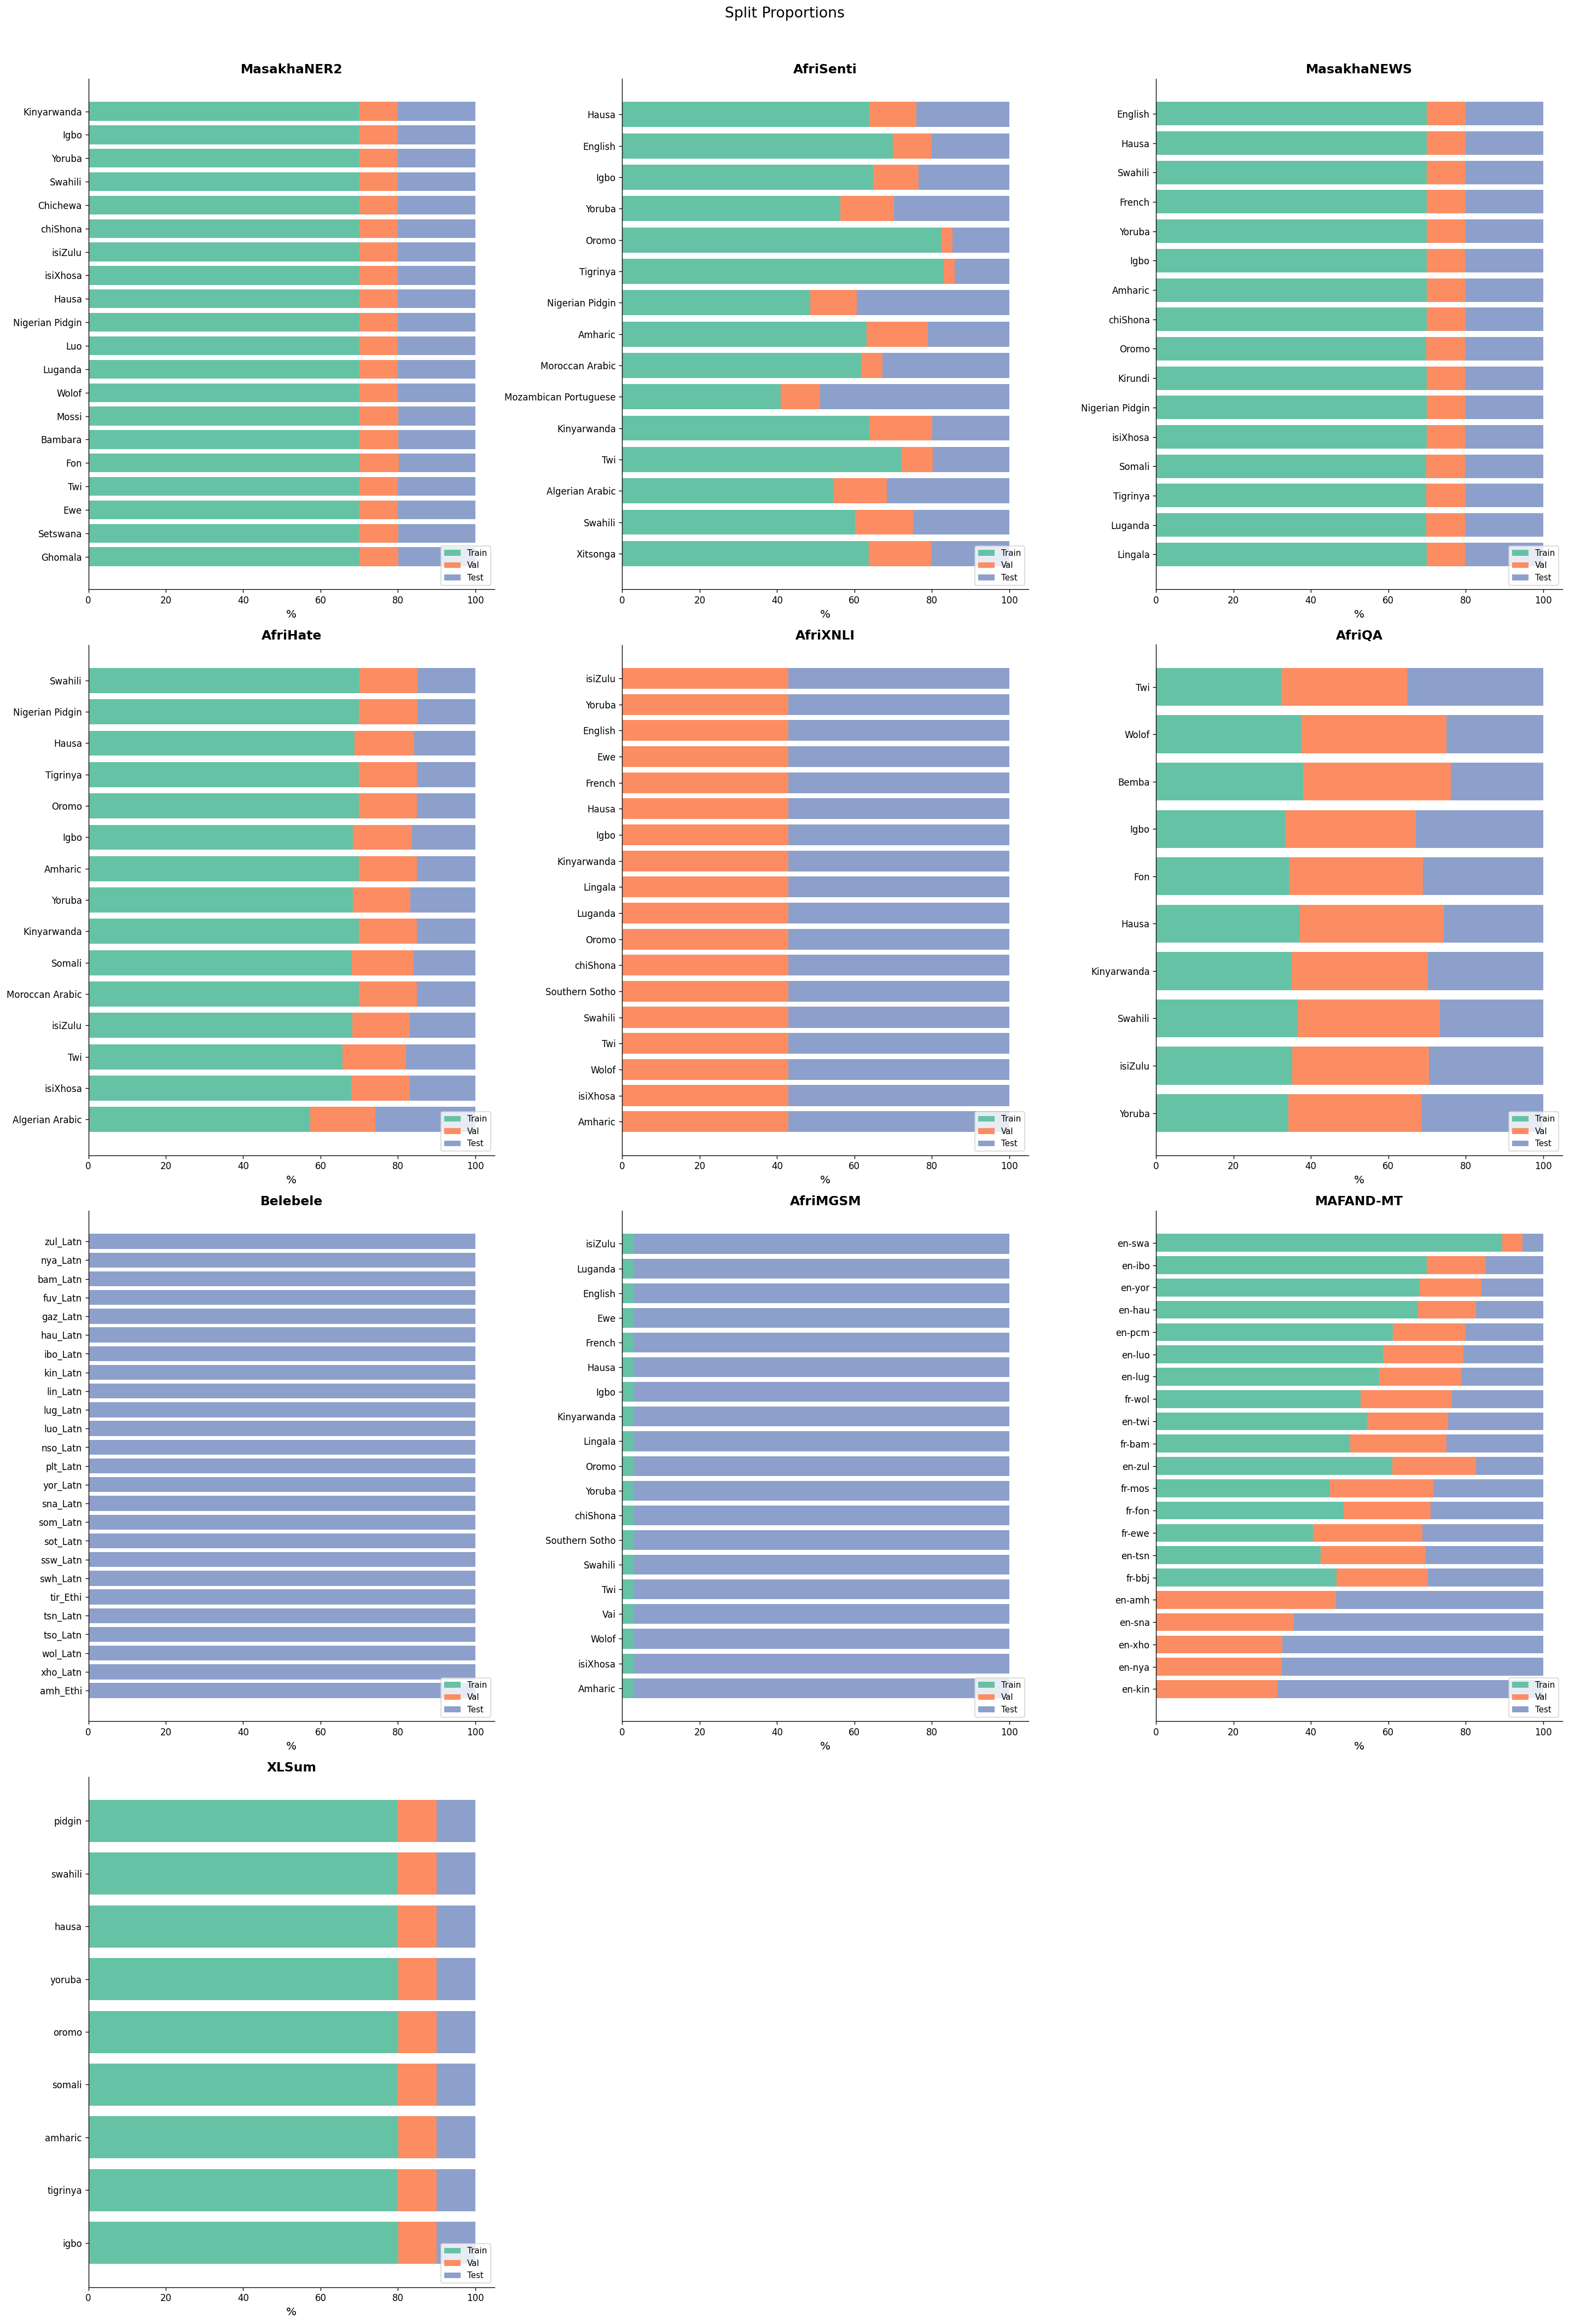

In [76]:
n_ds = len(SUMMARIES)
n_cols = 3
n_rows = (n_ds + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols,
    max(6, max(len(df) for df in SUMMARIES.values()) * 0.35) * n_rows))
axes = axes.flatten()

for ax, (ds_name, df) in zip(axes, SUMMARIES.items()):
    df_s = df.sort_values("n_total", ascending=True)
    y = np.arange(len(df_s))
    tr = df_s["n_train"]/df_s["n_total"]*100
    va = df_s["n_validation"]/df_s["n_total"]*100
    te = df_s["n_test"]/df_s["n_total"]*100
    ax.barh(y, tr, label="Train", color=PAL[0])
    ax.barh(y, va, left=tr, label="Val", color=PAL[1])
    ax.barh(y, te, left=tr+va, label="Test", color=PAL[2])
    ax.set_yticks(y); ax.set_yticklabels(df_s["language"])
    ax.set_xlabel("%"); ax.set_xlim(0, 105)
    ax.set_title(ds_name, fontsize=14, fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)

for i in range(n_ds, len(axes)):
    axes[i].set_visible(False)

plt.suptitle("Split Proportions", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

---
## Summary

In [84]:
# count real stats
n_datasets = len(REGISTRY)
all_l = set()
for data in ALL_DATA.values():
    for lang in data.keys():
        cfg_match = [c for n,c in REGISTRY.items() if n in [k for k,v in ALL_DATA.items() if lang in v]]
        if cfg_match and cfg_match[0].get("_lang_code_fn"):
            all_l.add(cfg_match[0]["_lang_code_fn"](lang))
        else:
            all_l.add(lang)
all_l -= {"eng", "en", "fra", "por"}  # exclude non-African

total_ex = sum(
    sum(len(ds[sp]) for sp in ds.keys())
    for data in ALL_DATA.values() for ds in data.values()
)

task_types = sorted(set(cfg["task_type"] for cfg in REGISTRY.values()))
families = sorted(set(lfamily(l) for l in all_l) - {"Unknown", "Other"})

# languages in all datasets
from collections import Counter
lang_counts = Counter()
for ds_name, data in ALL_DATA.items():
    cfg = REGISTRY[ds_name]
    fn = cfg.get("_lang_code_fn")
    for lang in data.keys():
        code = fn(lang) if fn else lang
        lang_counts[code] += 1
in_all = [l for l, c in lang_counts.items() if c == n_datasets and l not in {"eng","en","fra","por"}]
in_7plus = [l for l, c in lang_counts.items() if c >= 7 and l not in {"eng","en","fra","por"}]

print(f"""
======================================================================
KEY FINDINGS
======================================================================

BENCHMARK:  {n_datasets} datasets | {len(all_l)} unique African languages | {total_ex:,} total examples
TASKS:      {len(task_types)} types ({', '.join(task_types)})
FAMILIES:   {len(families)} ({', '.join(families)})
SCENARIOS:  Scenario 1 (verification) for 8 datasets | Scenario 2 (rating) for 2 datasets

COVERAGE:
  - {len(in_all)} languages in ALL {n_datasets} datasets: {sorted(lname(l) for l in in_all)}
  - {len(in_7plus)} languages in 7+ datasets -> strong cross-task evaluation candidates
  - {sum(1 for _,c in lang_counts.items() if c == 1)} languages in only 1 dataset -> task-specific evaluation only


NEXT STEPS:
  - Phase 1: Run LLM inference on test sets using AfroBench evaluation framework
  - Phase 2: Design LLM-as-a-Judge prompts for Scenario 1 (verification) and Scenario 2 (rating)
  - Phase 3: Compute judge agreement, bias metrics, and robustness across languages and families (RQ1-RQ4)
""")


KEY FINDINGS

BENCHMARK:  10 datasets | 36 unique African languages | 699,340 total examples
TASKS:      8 types (math_reasoning, nli, question_answering, reading_comprehension, summarization, text_classification, token_classification, translation)
FAMILIES:   5 (Afroasiatic, Austronesian, Niger-Congo (Bantu), Niger-Congo (non-Bantu), Nilo-Saharan)
SCENARIOS:  Scenario 1 (verification) for 8 datasets | Scenario 2 (rating) for 2 datasets

COVERAGE:
  - 4 languages in ALL 10 datasets: ['Hausa', 'Igbo', 'Swahili', 'Yoruba']
  - 10 languages in 7+ datasets -> strong cross-task evaluation candidates
  - 8 languages in only 1 dataset -> task-specific evaluation only


NEXT STEPS:
  - Phase 1: Run LLM inference on test sets using AfroBench evaluation framework
  - Phase 2: Design LLM-as-a-Judge prompts for Scenario 1 (verification) and Scenario 2 (rating)
  - Phase 3: Compute judge agreement, bias metrics, and robustness across languages and families (RQ1-RQ4)



## References

- Adelani, D. I. et al. (2022). *MasakhaNER 2.0: Africa-centric Transfer Learning for Named Entity Recognition*. EMNLP 2022. [Paper](https://aclanthology.org/2022.emnlp-main.298) | [Dataset](https://huggingface.co/datasets/masakhane/masakhaner2)

- Muhammad, S. H. et al. (2023). *AfriSenti: A Twitter Sentiment Analysis Benchmark for African Languages*. EMNLP 2023. [Paper](https://aclanthology.org/2023.emnlp-main.862) | [Dataset](https://huggingface.co/datasets/masakhane/afrisenti)

- Muhammad, S. H. et al. (2023). *SemEval-2023 Task 12: Sentiment Analysis for African Languages (AfriSenti-SemEval)*. [Paper](https://arxiv.org/abs/2304.06845)

- Adelani, D. I. et al. (2023). *MasakhaNEWS: News Topic Classification for African Languages*. IJCNLP-AACL 2023. [Paper](https://arxiv.org/abs/2304.09972) | [Dataset](https://huggingface.co/datasets/masakhane/masakhanews)

- Muhammad, S. H. et al. (2025). *AfriHate: A Multilingual Collection of Hate Speech and Abusive Language Datasets for African Languages*. NAACL 2025. [Paper](https://arxiv.org/abs/2501.08284) | [Dataset](https://huggingface.co/datasets/afrihate/afrihate)

- Adelani, D. I. et al. (2024). *IrokoBench: A New Benchmark for African Languages in the Age of Large Language Models*. [Paper](https://arxiv.org/abs/2406.03368) | Datasets: [AfriXNLI](https://huggingface.co/datasets/masakhane/afrixnli), [AfriMGSM](https://huggingface.co/datasets/masakhane/afrimgsm)

- Ogundepo, O. et al. (2023). *AfriQA: Cross-lingual Open-Retrieval Question Answering for African Languages*. EACL 2023. [Paper](https://aclanthology.org/2023.findings-eacl.15) | [Dataset](https://huggingface.co/datasets/masakhane/afriqa)

- Bandarkar, L. et al. (2024). *The Belebele Benchmark: A Parallel Reading Comprehension Dataset in 122 Language Variants*. ACL 2024. [Paper](https://aclanthology.org/2024.acl-long.44) | [Dataset](https://huggingface.co/datasets/facebook/belebele)

- Adelani, D. I. et al. (2022). *A Few Thousand Translations Go a Long Way! Leveraging Pre-trained Models for African News Translation*. NAACL 2022. [Paper](https://aclanthology.org/2022.naacl-main.223) | [Dataset](https://huggingface.co/datasets/masakhane/mafand)

- Hasan, T. et al. (2021). *XL-Sum: Large-Scale Multilingual Abstractive Summarization for 44 Languages*. Findings of ACL 2021. [Paper](https://aclanthology.org/2021.findings-acl.413) | [Dataset](https://huggingface.co/datasets/csebuetnlp/xlsum)

- Ojo, J. et al. (2025). *AfroBench: How Good are Large Language Models on African Languages?* Findings of ACL 2025. [Paper](https://aclanthology.org/2025.findings-acl.976)

- Gu, Z. et al. (2025). *A Survey on LLM-as-a-Judge*. [Paper](https://arxiv.org/abs/2411.15594)

- Masakhane Community: [masakhane.io](https://www.masakhane.io/) | [HuggingFace](https://huggingface.co/masakhane)